# 12. Sensitivity analysis

## Numerical experiments - Week 45/2025

_Boyan Mihaylov, MSc Computational Science (UVA/VU)_

The procedure presented below performs Bayesian Model Averaging (BMA) on the broad collection of models to
- assess their likelihood of representing the data (with its inherent variance),
- penalize overly complex models,
- assess the models' predictive capabilities
- and explore the combined predictive power of weighted combinations of models.

The aim is to obtain a list of models ranked by their pseudo-BMA weights, which evaluate predictive accuracy under uncertainty and are thus a better criterion than RMSE of model fits to data.

## Prerequisite libraries

In [1]:
using PyPlot
using Distributions
using QuasiMonteCarlo
using LinearAlgebra
using Random
using JLD2
using Revise

# include("../src/conversions.jl")
# include("../src/diffusion.jl")
# include("../src/setup.jl")
# include("../src/plotting.jl")
# include("../src/analysis.jl")
# include("../src/datautils.jl")
# include("../src/germstats.jl")

Revise.includet("../src/conversions.jl")
Revise.includet("../src/diffusion.jl")
Revise.includet("../src/setup.jl")
Revise.includet("../src/plotting.jl")
Revise.includet("../src/analysis.jl")
Revise.includet("../src/datautils.jl")
Revise.includet("../src/germstats.jl")

using .Conversions
using .Diffusion
using .Setup
using .Plotting
using .Analysis
using .DataUtils
using .GermStats

## 1. Parameter priors

The first step is to assume prior distributions of the model parameters, which encode the expectations of plausible parameter values before relating them to data.

### 1.1. Parameter summary

The free parameters in the germination models are:

- $P_s^\textrm{I}$ - the permeation coefficient of the inhibitor molecule through the cell wall;
- $P_s^\textrm{C}$ - the permeation coefficient of the inducer molecule (carbon source) through the cell wall;
- $K_\textrm{I}$ - the half-saturation constant of the inhibitor when directly blocking the inducing signal;
- $K_\textrm{I}^\Delta$ - the half-saturation constant of the inhibitor when shifting the induction threshold or permeability;
- $K_\textrm{C}^\Delta$ - the half-saturation constant of the inducer when shifting the inhibition threshold or permeability;
- $s$ - scaling factor of the permeability perturbation caused by the inducing signal;
- $b$ - scaling factor of the permeability perturbation caused by the inhibitory signal;
- $k_\textrm{I}$ - scaling factor of the induction threshold shift caused by the inhibitory signal;
- $k_\textrm{C}$ - scaling factor of the inhibition threshold shift caused by the inducing signal;
- $n$ - Hill exponent of the direct inhibition of the inducing signal;
- $\mu_\gamma$ - mean of the inhibition threshold;
- $\sigma_\gamma$ - standard deviation of the inhbition threshold;
- $\mu_\omega$ - mean of the induction threshold;
- $\sigma_\omega$ - standard deviation of the induction threshold;
- $\mu_\psi$ - mean of the initial inhibitor concentration in the spore;
- $\sigma_\psi$ - standard deviation of the initial inhibitor concentration in the spore.

Some of these parameters are independent of the type of carbon source, others are inducer-specific and therefore get a specific instance (with its own distribution) in each inducer case. The inducer-specific parameters are $P_s^\textrm{C}$, $K_\textrm{I}$, $K_\textrm{I}^\Delta$, $K_\textrm{C}^\Delta$, $s$, $k_\textrm{I}$, $k_\textrm{C}$, $n$, $\mu_\omega$, $\sigma_\omega$. On the other hand, $P_s^\textrm{I}$, $b$, $\mu_\gamma$, $\sigma_\gamma$, $\mu_\psi$ and $\sigma_\psi$ are general for all inducer cases.

### 1.2. Determining the priors

Since an exact quantification of the prior distributions is generally difficult to infer from literature, several approaches can be employed to narrow down the bounds, shape an scale of each parameter prior:

1. Use biologically plausible bounds and shapes wherever known.
2. If not known, use log-normal distributions within generously wide bounds, such that 95% of the distribution fall within the bounds.
3. Sample the parameter space, fit the Dantigny triplets to each parameter sample and inspect the distributions of the Dantigny triplets. If a large discrepancy is noticeable compared to recorded data (certain values of a parameter consistently yield unplausible $p_{\textrm{max}}$, $\tau_g$ or $\nu$), narrow down the bounds accordingly. (Prior predictive checks)

#### 1.2.1. Initial guesses

It has been shown that to achieve realistic inhibitor depletion within 4 hours, $P_s^\textrm{I}$ needs to be in the order of $10^{-9}\ \textrm{cm/s}$ to $10^{-7}\ \textrm{cm/s}$. However, inference from physical properties points at a permeability closer to the range of $10^{-5}\ \textrm{cm/s}$ to $10^{-3}\ \textrm{cm/s}$. If strong adsorption is at hand, the former permeability range can be taken, arguing that the adsorption effect is implicit in the low permeation values. However, one could also argue that the permeability is as high as the physics suggest, but it is some secondary interactions that slow down the permeation trigger. Therefore, the high-permeability range is to be considered as well. This results in the liberal bounds of $10^{-9}\ \textrm{cm/s}$ to $10^{-3}\ \textrm{cm/s}$. It should be noted that in some models the permeation coefficient is taken as a base for a temporally modulated shift and in others it remains constant.

As for $P_s^\textrm{C}$, it can remain relatively high if the hydrophobin layer is barely limiting ($10^{-3}\ \textrm{cm/s}$) or extremely low if the full blocking potential of a hydrophobin layer is considered ($10^{-11}\ \textrm{cm/s}$). The first case is conceivable e.g. when an inhibitor-dependent permeability shift is removed, analogous to a deconstruction of the outer cell wall. Thus, a range of $10^{-11}\ \textrm{cm/s}$ to $10^{-3}\ \textrm{cm/s}$ can be assumed.

Regarding $s$ and $b$, it can be assumed that the maximum permeability shift is usually close to the permeability value itself. If an inducer-mediated degradation of the hydrophobin layer triggers a shift of the effective permeability from $10^{-11}\ \textrm{cm/s}$ to $10^{-3}\ \textrm{cm/s}$ (in the most radical case), then a relative shift in the order of $10^8$ can be expected for $s$. Since $b$ perturbs the permeability factor downward, it cannot exceed $1$, or else it may render the term negative. The lower bound for both permeability shifts could be e.g. three orders smaller until it is considered to lose its tangible effect. This yields relative shifts of $10^{-3}$ to $10^8$ for $s$ and $10^{-3}$ to $1$ for $b$.

**This necessitates an important correction to the models.** In all cases where the permeability is perturbed, all cases beyond the extreme perturbation should be smoothly limited to sensible biological bounds. For both 1-octen-3-ol and glucose, the permeation constant through a $400\ \textrm{nm}$ thick cell wall is in the order of $10^{-1}\ \textrm{cm/s} = 10^{3}\ \mu\textrm{m/s}$. Defining the concentration-dependent perturbation term as

$$
\Delta{g}_{\textrm{C}} = s \frac{c_{\textrm{in}}^\textrm{C}}{K_\textrm{C}^\Delta+c_{\textrm{in}}^\textrm{C}},
$$

such that

$$
P_{\textrm{perturbed}}=(1+\Delta{g}_{\textrm{C}})P_{\textrm{base}},
$$

one can reformulate this as

$$
P_{\textrm{perturbed}}=P_{\textrm{max}}(1+e^{-(1+\Delta{g}_{\textrm{C}})P_{\textrm{base}}/P_{\textrm{max}}}).
$$

where $P_{\textrm{max}} = 10^{3}\ \mu\textrm{m/s}$. For small $x$, the approximation $1-e^{-x}\approx x$ holds, so when $s$ is small and the difference between $P_{\textrm{base}}$ and $P_{\textrm{max}}$ is large, $P_{\textrm{perturbed}}\approx (1+\Delta{g})P_{\textrm{base}}$ and the perturbation is approximately linear, as applied so far. However, as the exponent grows, the term saturates to the value of $P_{\textrm{max}}$, which is hard-coded in the current model procedures. Similarly, for the inhibitor-mediated permeability perturbation,

$$
\Delta{g}_{\textrm{I}} = b \frac{c_{\textrm{in}}^\textrm{I}}{K_\textrm{I}^\Delta+c_{\textrm{in}}^\textrm{I}},
$$

such that

$$
P_{\textrm{perturbed}}=(1-\Delta{g}_{\textrm{I}})P_{\textrm{base}},
$$

a limiting function can be used instead, such that the permeability approaches zero at large $b$, but never becomes negative, and remains linear for small $\Delta{g}_{\textrm{I}}$:

$$
P_{\textrm{perturbed}}=P_{\textrm{base}}e^{-\Delta{g}_{\textrm{I}}}.
$$

This allows $b$ to take larger values - at a magnitude ot $10$, the effect can be considered negligible. In the combined perturbation case, the formula becomes

$$
P_{\textrm{perturbed}}=P_{\textrm{max}}(1-e^{-(1+\Delta{g}_{\textrm{C}})e^{-\Delta{g}_{\textrm{I}}/(1+\Delta{g}_{\textrm{C}})}P_{\textrm{base}}/P_{\textrm{max}}}).
$$

$\mu_\psi$ has previously been estimated around $10^{-5} \ \textrm{M}$ based on experimental observations of minimum excreted 1-octen-3-ol. It is possible that a large portion of 1-octen-3-ol remained bound to the polysaccharide matrix upon measurement - an upper bound of $10^{-3} \ \textrm{M}$ could accommodate such a possibility.

$K_\textrm{I}$, $K_\textrm{I}^\Delta$ and $K_\textrm{C}^\Delta$ can all be related to typical molecular concentrations of the inhibitor and the inducer inside the spore. For the respective Michaelis-Menten-like relation, it can be said the effect becomes relatively negligible when the half-saturation constant is more than a thousand times larger than a typical concentration. Based on $\mu_\psi$, this amounts to an upper extreme of $1\ \textrm{M}$ for the inhibitor. The characteristic internal inducer concentration, on the other hand, is highly dependent on the cell wall permeability and the external availability of inducing molecules. In the case of fast equilibration of the currently considered external concentration of $0.01\ \textrm{M}$, the upper bound for the inducer half-concentration could be set to $10\ \textrm{M}$. Conversely, an extremely low half-saturation would imply extreme sensitivity to molecular concentrations. A lower bound of $10^{-9}\ \textrm{M}$ reasonably links the visible effects to merely hundreds of molecules. At this point, however, both the inhibitor and the inducer are expected to have little to no effect - which implies that the half-saturation constants should be placed at least an order higher. Thus, bounds of $10^{-8}\ \textrm{M}$ to $1\ \textrm{M}$ for $K_\textrm{I}$ and $K_\textrm{I}^\Delta$, and $10^{-8}\ \textrm{M}$ to $10\ \textrm{M}$ for $K_\textrm{C}^\Delta$, can be considered.

The inhibition and induction thresholds are parameters conceived for the purpose of the current research and quantitative evidence is difficult to obtain from literature. Nonetheless, an upper bound can be correlated with the maximum viable concentration of the respective molecular species. A lower bound can be related to a rough guess on the minimal effective concentration, as with the half-saturation constants. In the inhibitor case, the threshold can either be an absolute concentration quantity or a fraction relating to the original concentration. In the first case, the bounds range from $10^{-9}\ \textrm{M}$ to $10^{-3}\ \textrm{M}$ and, in the second case, from $10^{-6}$ (a depletion of the $\mu_\psi$ maximum to a few hundred molecules) to $1$ time the maximum $\mu_\psi$ in the case of immediate threshold crossing. The induction threshold, always an absolute concentration, could range from $10^{-9}\ \textrm{M}$ to $10^{-1}\ \textrm{M}$, relfecting in the lower bound a sensitivity to a few hundred molecules, and in the upper bound the case of a mean threshold that is just below achievable by standard ambient inducer concentrations (10 times too high), but possibly effective via the large width of its variance.

Similar to the permeability shift, the size of the threshold shifts $k_\textrm{I}$ and $k_\textrm{C}$ needs to be aligned with the scale of the threshold itself. Since the inhibitor has an absolute and a relative scale, two different scales should also apply to $k_\textrm{C}$, the inducer-dependent inhibition threshold shift factor. In the first case, a lower bound could reflect a minor nudge with the already established $10^{-9}\ \textrm{M}$ effective concentration and an upper bound could imply a shift from the minimum effective concentration to a degree that overshoots the possible threshold maximum a thousand times, rendering inhibition completely ineffective by the influence of the inducer. This implies bounds of $10^{-9}\ \textrm{M}$ to $1\ \textrm{M}$ for $k_\textrm{C}$. Seen on a relative scale, the minimum effective shift is $10^{-6}$ times smaller than the maximum viable concentration, hence the bounds can be set to $10^{-6}$ to $10^{3}$. The (absolute-scaled) inhibitor-dependent induction threshold shift, $k_\textrm{I}$, can analogically be limited to $10^{-9}\ \textrm{M}$ and $1\ \textrm{M}$.

There is no concrete evidence that inhibition of the induction signal occurs through direct ligation of VOCs to receptor proteins. If 1-octen-3-ol would inhibit via ligation, then a Hill exponent of 1 to 3 would make most sense, since a higher coefficient has not been documented in the context of fungi to the knowledge of the author [1] and a coefficient lower than 1 would imply negative cooperativity [2], which is ruled out for simplicity in the current study.

The bounds of all standard deviations can be related to the respective means under consideration of the heterogeneity among _Aspergillus_ conidia. A logical upper bound would be in the order of the respective mean, as the thresholds or initial concentration would unlikely vary by far beyond their characteristic size. On the other hand, an overly tight variance is also unlikely: for the initial inhibitor concentration this is due to the known physiological differences between spores, and for the thresholds it is due to the likely complex network of variables concealed behind the assumed parameters. Once again, a thousandth of the mean could be considered the lowest bound of effective difference. Thus, the bounds for $\sigma_\gamma$, $\sigma_\omega$ and $\sigma_\psi$ can all be set to $10^{-3}$ to $1$ times their respective means. This relationship can be expressed in terms of the relation exponents $\delta$, such that $\sigma=\mu e^\delta$.

**Summary of initial bound estimates:**

Parameter | Lower bound | Upper bound
----------|-------------|-------------
$P_s^\textrm{I}$|$10^{-5}\ \mu\textrm{m/s}$|$10\ \mu\textrm{m/s}$
$P_s^\textrm{C}$|$10^{-7}\ \mu\textrm{m/s}$|$10\ \mu\textrm{m/s}$
$K_\textrm{I}$|$10^{-8}\ \textrm{M}$|$1\ \textrm{M}$
$K_\textrm{I}^\Delta$|$10^{-8}\ \textrm{M}$|$1\ \textrm{M}$
$K_\textrm{C}^\Delta$|$10^{-8}\ \textrm{M}$|$10\ \textrm{M}$
$s$|$10^{-3}$|$10^8$
$b$|$10^{-3}$|$10$
$k_\textrm{I}$|$10^{-9}\ \textrm{M}$|$1\ \textrm{M}$
$k_\textrm{C}$|$10^{-9}\ \textrm{M}$ (absolute), $10^{-6}$ (relative)|$1\ \textrm{M}$ (absolute), $10^{3}$(relative)
$n$|1|3
$\mu_\gamma$|$10^{-9}\ \textrm{M}$ (absolute), $10^{-6}$|$10^{-3}\ \textrm{M}$ (absolute), $1$ (relative)
$-\delta_\gamma$|$0$|$4$
$\mu_\omega$|$10^{-9}\ \textrm{M}$|$10^{-1}\ \textrm{M}$
$-\delta_\omega$|$0$|$4$
$\mu_\psi$|$10^{-5} \ \textrm{M}$|$10^{-3} \ \textrm{M}$
$-\delta_\psi$|$0$|$4$

Using the loosely defined parameter bounds, log-normal distributions (implied by the strict positivity of the parameters) can be constructed by fitting $95\%$ of the probability inside the bounds $[a, b]$. To this end, one needs to define

$$
\mu=\frac{\ln{a}+\ln{b}}{2}
$$

and

$$
\sigma=\frac{\ln{b} - \ln{a}}{2\cdot 1.96}
$$

as the parameters of each log-normal distribution. The initial priors are visualised below.

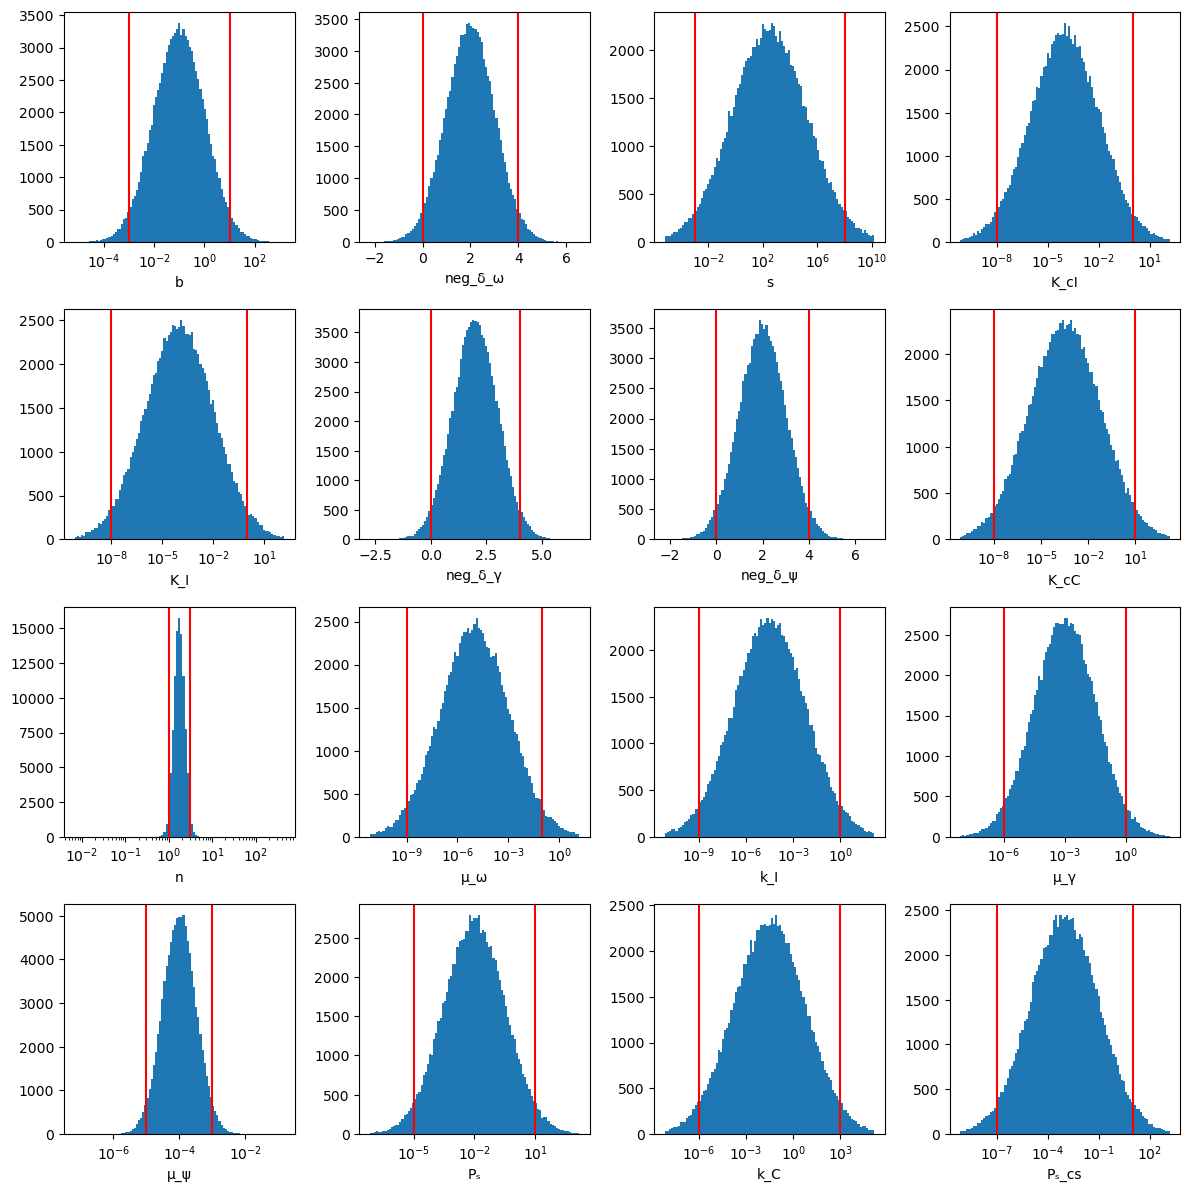

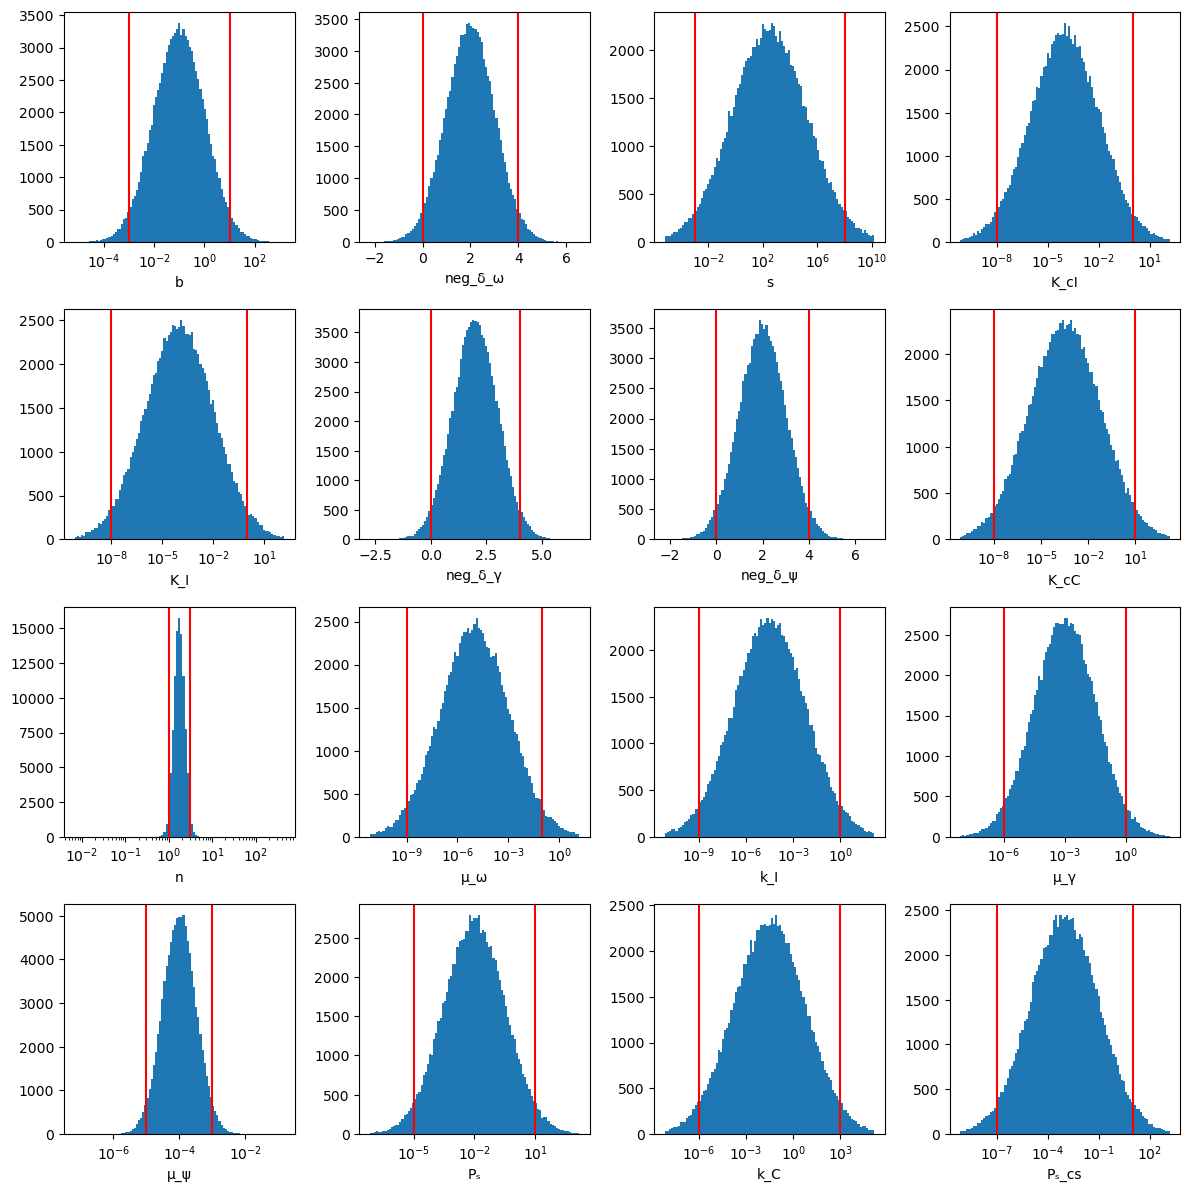

In [2]:
bounds_abs = Dict(
    :Pₛ     => (1e-5, 10),
    :Pₛ_cs  => (1e-7, 10),
    :K_I    => (1e-8, 1),
    :K_cI   => (1e-8, 1),
    :K_cC   => (1e-8, 10),
    :s      => (1e-3, 1e8),
    :b      => (1e-3, 10),
    :k_I    => (1e-9, 1),
    :k_C    => (1e-9, 1),
    :n      => (1, 3),
    :μ_γ    => (1e-9, 1e-3),
    :neg_δ_γ => (0, 4),
    :μ_ω    => (1e-9, 1e-1),
    :neg_δ_ω => (0, 4),
    :μ_ψ    => (1e-5, 1e-3),
    :neg_δ_ψ => (0, 4)
)

bounds_rel = Dict(
    :Pₛ     => (1e-5, 10),
    :Pₛ_cs  => (1e-7, 10),
    :K_I    => (1e-8, 1),
    :K_cI   => (1e-8, 1),
    :K_cC   => (1e-8, 10),
    :s      => (1e-3, 1e8),
    :b      => (1e-3, 10),
    :k_I    => (1e-9, 1),
    :k_C    => (1e-6, 1e3),
    :n      => (1, 3),
    :μ_γ    => (1e-6, 1),
    :neg_δ_γ => (0, 4),
    :μ_ω    => (1e-9, 1e-1),
    :neg_δ_ω => (0, 4),
    :μ_ψ    => (1e-5, 1e-3),
    :neg_δ_ψ => (0, 4)
)

# Compute histograms
data = Dict()
for (key, val) in bounds_rel
    if startswith(string(key), "neg_δ_")
        mean = 0.5 * (val[1] + val[2])
        sd = (val[2] - val[1]) / (2 * 1.96)
        dist = Normal(mean, sd)
    else
        mean = (log(val[1]) + log(val[2])) * 0.5
        sd = (log(val[2]) - log(val[1])) / (2 * 1.96)
        dist = LogNormal(mean, sd)
    end
    data[key] = rand(dist, 100000)
end

matplotlib.pyplot.close()

fig, axs = subplots(4, 4, figsize=(12, 12))
# println(size(axs))
axs = vec(axs)

for (i, key) in enumerate(keys(bounds_rel))

    # Log bins
    if startswith(string(key), "neg_δ_")
        axs[i].hist(data[key], bins=100)
    else
        bins = exp.(LinRange(log(bounds_rel[key][1])-5, log(bounds_rel[key][2])+5, 100))
        axs[i].hist(data[key], bins=bins)
        axs[i].set_xscale("log")
    end

    axs[i].axvline(bounds_rel[key][1], color="red")
    axs[i].axvline(bounds_rel[key][2], color="red")
    axs[i].set_xlabel(key)
end

tight_layout()
gcf()

#### 1.2.2. Prior calibration

Next, space-filling (Sobol) samples (2048 per parameter) are taken from each prior, for each model, and used to run germination simulations. After each run, a Dantigny triplet is fit to the germination curve using Linear Least-Squares and is recorded. For each spore density and inducer type in Ijadpanahsaravi et al. [3], the newly fitted Dantigny parameter distributions are compared to the documented ones, trying to identify whether certain parameter regions produce mismatching statistics.

The utility procedure below explores variations within a single parameter, using the mean values of the remaining parameters, and tests the non-linear squares fitting of the Dantigny triplets.

Dict{Any, Any}(:b => 0.10000000000000002, :σ_ψ => 4.9999999999999955e-5, :c₀_cs => 0.01, :K_I => 9.999999999999991e-5, :n => 1.7320508075688774, :μ_ψ => 9.999999999999991e-5, :μ_κ => 0.2, :μ_ω => 9.999999999999997e-6, :σ_ω => 4.999999999999999e-6, :Pₛ => 0.009999999999999995, :σ_ξ => 0.3, :μ_ξ => 2.65, :d_hp => 0.01, :s => 0.0010002327350563944, :σ_κ => 0.05, :k_I => 3.16227766016838e-5, :σ_γ => 5.000000000000002e-7, :k_C => 3.16227766016838e-5, :K_cI => 9.999999999999991e-5, :K_cC => 0.00031622776601683783, :μ_γ => 1.0000000000000004e-6, :Pₛ_cs => 0.0010000000000000002)
Dict{Any, Any}(:b => 0.10000000000000002, :σ_ψ => 4.9999999999999955e-5, :c₀_cs => 0.01, :K_I => 9.999999999999991e-5, :n => 1.7320508075688774, :μ_ψ => 9.999999999999991e-5, :μ_κ => 0.2, :μ_ω => 9.999999999999997e-6, :σ_ω => 4.999999999999999e-6, :Pₛ => 0.009999999999999995, :σ_ξ => 0.3, :μ_ξ => 2.65, :d_hp => 0.01, :s => 0.05113009102132699, :σ_κ => 0.05, :k_I => 3.16227766016838e-5, :σ_γ => 5.000000000000002e-7, :k_

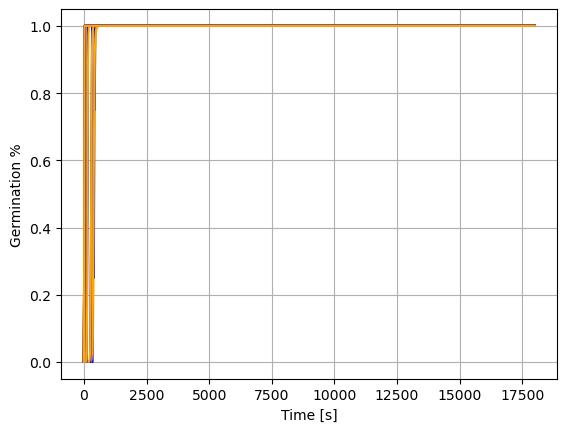

In [ ]:
matplotlib.pyplot.close()

# Parameter sample
n_samples = 16
varied_param_key = :s
param_bounds = bounds_abs
varied_param = Dict()
non_varied_params = Dict()
for (key, val) in param_bounds
    mean = (log(val[1]) + log(val[2])) * 0.5
    if key == varied_param_key
        sd = (log(val[2]) - log(val[1])) / (2 * 1.96)
        dist = LogNormal(mean, sd)
        
        # println(collect(LinRange(val[1], val[2], n_samples)))
        samples = quantile.(dist, LinRange(0.025, 0.975, n_samples))

        # Transform sigmas
        if startswith(string(key), "neg_δ_")
            suffix = string(key)[end]
            mean_bnds_match = param_bounds[Symbol("μ_" * suffix)]
            mean_match = exp((log(mean_bnds_match[1]) + log(mean_bnds_match[2])) * 0.5)
            varied_param[Symbol("σ_" * suffix)] = mean_match .* exp(-samples)
        else
            varied_param[key] = samples
        end
    else
        # Transform sigmas
        if startswith(string(key), "neg_δ_")
            suffix = string(key)[end]
            mean_bnds_match = param_bounds[Symbol("μ_" * suffix)]
            mean_match = exp((log(mean_bnds_match[1]) + log(mean_bnds_match[2])) * 0.5)
            non_varied_params[Symbol("σ_" * suffix)] = mean_match .* exp(-mean)
            # println("transformed $(Symbol("σ_" * suffix)) to $(mean_match .* exp(-mean))")
        else
            non_varied_params[key] = exp(mean)
        end
    end
end

# Default parameters
def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)

# example_params = Dict(
#     :μ_ξ => 2.65,
#     :σ_ξ => 0.3,
#     :c₀_cs => 0.01,
#     :d_hp => 0.01,
#     :μ_κ => 0.2,
#     :σ_κ => 0.05,
#     :Pₛ => 5e-3,
#     :Pₛ_cs => 1e-5,
#     :μ_γ => 1e-3,
#     :σ_γ => 1e-4,
#     :μ_ω => 1e-3,
#     :σ_ω => 1e-4,
#     :s => 0.5,
#     :b => 0.95,
#     :μ_ψ => 0.5,
#     :σ_ψ => 0.01,
#     :K_cC => 0.01,
#     :K_cI => 0.01,
#     :K_I => 0.01,
#     :k_C => 0.1,
#     :n => 2,
#     :k_I => 1.0
# )

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 1000)
density_test = inverse_mL_to_cubic_um(1e5)

matplotlib.pyplot.close()
fig, ax = subplots()

for i in 1:n_samples

    # println(i)

    varied_param_sample = Dict(varied_param_key => varied_param[varied_param_key][i])
    sample_params = merge(varied_param_sample, non_varied_params, def_params)

    println(sample_params)

    p_out = compute_germination_response("feedback_combined_inducer_perm", times_eval, density_test, sample_params)

    (p_max, τ_g, ν), _ = fit_dantigny_to_germination_curve(p_out, times_eval)
    p_fit = dantigny.(times_eval, p_max, τ_g, ν)

    ax.plot(times_eval, p_out, color="blue")
    ax.plot(times_eval, p_fit, color="orange")
end

ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [ ]:
t_max = 48 # hours

# Default parameters
def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)

# Load data
aliases, combination_IDs, descriptions, param_key_sets = load_model_collection()
df_germination_rebuilt = parse_ijadpanahsaravi_data()
df_germination_rebuilt = filter(row -> row[1] != "Arg", df_germination_rebuilt) # Remove "Arg" from the dataset
dantigny_data, times, sources, densities, _, p_maxs, taus, nus = generate_dantigny_dataset(df_germination_rebuilt, t_max)
times_sec = times * 3600 # for matching physics variables in mechanistic model

# println(df_germination_rebuilt)

# Number of Sobol samples per parameter
n_samples = 2048

# Determine relative vs absolute threshold models
aliases_rel = ["0", "B", "Bi"]

# Precompute distributions
param_dists_abs = Dict()
for (key, val) in bounds_abs
    if startswith(string(key), "neg_δ_")
        mean = 0.5 * (val[1] + val[2])
        sd = (val[2] - val[1]) / (2 * 1.96)
        param_dists_abs[key] = Normal(mean, sd)
    else
        mean = (log(val[1]) + log(val[2])) * 0.5
        sd = (log(val[2]) - log(val[1])) / (2 * 1.96)
        param_dists_abs[key] = LogNormal(mean, sd)
    end
end

param_dists_rel = Dict()
for (key, val) in bounds_rel
    if startswith(string(key), "neg_δ_")
        mean = 0.5 * (val[1] + val[2])
        sd = (val[2] - val[1]) / (2 * 1.96)
        param_dists_rel[key] = Normal(mean, sd)
    else
        mean = (log(val[1]) + log(val[2])) * 0.5
        sd = (log(val[2]) - log(val[1])) / (2 * 1.96)
        param_dists_rel[key] = LogNormal(mean, sd)
    end
end

# Run samples
p_maxs = zeros(Float64, length(aliases), length(densities), n_samples)
taus = zeros(Float64, length(aliases), length(densities), n_samples)
nus = zeros(Float64, length(aliases), length(densities), n_samples)
rmses = zeros(Float64, length(aliases), length(densities), n_samples)

# Iterate over models
for m in eachindex(aliases)

    # Generate (normalized) parameter samples
    n_dims = length(param_key_sets[m])
    sobol_pts = QuasiMonteCarlo.sample(n_samples, n_dims, SobolSample())

    # Iterate over experimental conditions
    for (i, density) in enumerate(densities) # iterate over spore densities (exp. data)

        println("Running model $(aliases[m]) with density $density")

        density_scaled = inverse_mL_to_cubic_um(density)

        for n in 1:n_samples # iterate over random parameter samples

            # Check if model uses absolute or relative bounds
            if aliases[m] in aliases_rel
                sample_dists = filter(p -> p[1] in param_key_sets[m], param_dists_rel)
            else
                sample_dists = filter(p -> p[1] in param_key_sets[m], param_dists_abs)
            end

            # Create parameter samples
            sample_params = Dict()
            for (k, key) in enumerate(param_key_sets[m])
                sample_params[key] = quantile(sample_dists[key], 0.025 + 0.95*sobol_pts[k, n]) # limit to sampling to 95% within bounds
            end

            # Transform sigmas
            for key in param_key_sets[m]
                if startswith(string(key), "neg_δ_")
                    suffix = string(key)[end]
                    sample_params[Symbol("σ_" * suffix)] = sample_params[Symbol("μ_" * suffix)] * exp(-sample_params[key])
                end
            end

            # println(sample_params)
            # println(n)

            # try
            p_out = compute_germination_response(aliases[m], times_sec, density_scaled, merge(sample_params, def_params))
            (p_maxs[m, i, n], taus[m, i, n], nus[m, i, n]), rmses[m, i, n] = fit_dantigny_to_germination_curve(p_out, times)
            # catch
            #     println(sample_params)
            # end
        end
    end
end

jldopen("../src/Data/prior_predictive_checks.jld2", "w") do file
    file["sources"] = sources
    file["densities"] = densities
    file["param_dists_rel"] = param_dists_rel
    file["param_dists_abs"] = param_dists_abs
    file["p_maxs"] = p_maxs
    file["taus"] = taus
    file["nus"] = nus
    file["rmses"] = rmses
end

Running model independent with density 33333.333333333336
Running model independent with density 66666.66666666667
Running model independent with density 133333.33333333334
Running model independent with density 266666.6666666667
Running model feedback_combined_inducer_perm with density 33333.333333333336
Running model feedback_combined_inducer_perm with density 66666.66666666667
Running model feedback_combined_inducer_perm with density 133333.33333333334
Running model feedback_combined_inducer_perm with density 266666.6666666667
Running model feedback_combined_inducer_perm_thresh with density 33333.333333333336
Running model feedback_combined_inducer_perm_thresh with density 66666.66666666667
Running model feedback_combined_inducer_perm_thresh with density 133333.33333333334
Running model feedback_combined_inducer_perm_thresh with density 266666.6666666667
Running model feedback_combined_inducer_perm_thresh_inhibitor_signal with density 33333.333333333336
Running model feedback_combin

58×4×2048 Array{Float64, 3}:
[:, :, 1] =
 0.00252676  0.00302411  0.00120254  1.1902e-5
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  2.39776e-8  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 ⋮                                   
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76502e-9  1.76502e-9  1.76502e-9  1.76502e-9
 1.76498e-9  1.76493e-9  3.2102e-9   7.47003e-10
 1.76477e-9  1.76477e-9  1.76477e-9  1.76477e-9
 1.76477e-9  1.76477e-9  1.76477e-9  1.76477e-9
 1.76502e

Model testing procedure below:

In [12]:
t_max = 48 # hours

# Default parameters
def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)

# Load data
aliases, combination_IDs, descriptions, param_key_sets = load_model_collection()
df_germination_rebuilt = parse_ijadpanahsaravi_data()
df_germination_rebuilt = filter(row -> row[1] != "Arg", df_germination_rebuilt) # Remove "Arg" from the dataset
dantigny_data, times, sources, densities, _, p_maxs, taus, nus = generate_dantigny_dataset(df_germination_rebuilt, t_max)

example_params = Dict{Any, Any}(:σ_ψ => 9.972511613538009e-6, :K_I => 4.391742024664157e-6, :n => 1.782820329952726, :μ_ψ => 0.000124500237909398, :neg_δ_γ => 2.628292400788087, :Pₛ => 0.03594753172429185, :neg_δ_ψ => 2.5244751574687188, :σ_γ => 5.242627157087572e-5, :k_C => 4.012770320178636e-6, :K_cC => 0.00025421643104326557, :μ_γ => 0.0007261090661001176, :Pₛ_cs => 1.2676361733721697)
p_out = compute_germination_response("inhibitor_thresh_inducer_signal", times * 3600, inverse_mL_to_cubic_um(266666.6666666667), merge(example_params, def_params))

# fit_dantigny_to_germination_curve(p_out, times)

1000-element Vector{Float64}:
 0.0
 0.49927351526627134
 0.9999999999999991
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 ⋮
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992
 0.9999999999999992

The Dantigny triplets retrieved by the parameter fitting, related to each model parameter, are compared to the Dantigny values obtained from literature. This helps the identification of unsensible parameter values for each specific model in order to narrow down the distributions for the forthcoming procedures. In particular, **soft weighting** is performed on each parameter sample $s$ from the weakly informative initial prior guesses with consideration of the Mahalanobis distance to the literature-based Dantigny triplet distributions. The weights are based on the formula

$$
w^{(s)}=\exp{(-\alpha z^{(s)})},
$$

where $\alpha$ is a tempering parameter set to 0.25 and $z^{(s)}$ is a summary discrepancy score formed by

$$
z^{(s)}=\sum_c{(d_c^{(s)}-\hat{d}_c)\ \Sigma_c^{-1}\ (d_c^{(s)}-\hat{d}_c)}.
$$

This means, for each experimental condition $c$ (combination of a carbon source and a spore culture density), the experimental summaries from [3]

$$
\hat{d}_c=(\hat{p}_{\textrm{max}}, \hat{\tau}_g, \hat{\nu}),\quad \textrm{CI}_c,
$$

are compared against the newly simulated ones, $d_c^{(s)}$. Furthermore, the diagonal covariance matrix $\Sigma_c$ assumes zero correlation:

$$
\Sigma_c=\begin{pmatrix}
\sigma^2_{p_\textrm{max}, c} & 0 & 0 \\
0 & \sigma^2_{\tau, c} & 0 \\
0 & 0 & \sigma^2_{\nu, c}
\end{pmatrix}.
$$

Since the degrees of freedom used for fitting the original experimental summaries are assumed large enough, the standard deviations can be obtained from the confidence intervals through the approximation

$$
\sigma_{i,c}\approx \frac{\Delta_{i,c}}{1.96},
$$

where $\Delta_{i,c} = (\textrm{CI}_{\textrm{U}}-\textrm{CI}_{\textrm{L}})/2$.

The experimental condition $c$ can be interpreted differently depending on the type of parameter. Parameters independent of the carbon source (regarded as global, such as $P_s^{\textrm{I}}$) take into account the different combinations of carbon source and spore culture density as distinct conditions, therefore require global scores $z^{(s)}$ and a global weights $w^{(s)}$. Parameters that vary with the carbon source, such as $P_s^{\textrm{C}}$ imply distinct $z_{\textrm{C}}^{(s)}$ score and weight $w_{\textrm{C}}^{(s)}$ per carbon source. Since each weight is assigned to the entire parameter vector, one needs to compute both sets of weights for the entirety of the parameters:
- global weights $w^{(s)}$ - stating whether a parameter set is more generally compatible with biology;
- inducer-specific weights $w_{\textrm{C}}^{(s)}$ - stating whether a parameter set is plausible under a given carbon source.

These two types of weights will be used later to calibrate both the marginal distributions of the parameter priors and their interactions under specific inducer cases.

Finally, since the Dantigny triplets fit to the model results bear an inherent error, expressed by the RMSE, its value is used to formulate a reliability factor $r\in[0,1]$ that may downweight the sample contribution if the fit is less successful:

$$
r^{(s)}=\exp{\left(-\frac{|\textrm{RMSE}_s^2|_c}{2\sigma_{\textrm{fit}}^2}\right)}.
$$

Here $|\textrm{RMSE}_s^2|_c=\frac{1}{C}\sum_c^C{\textrm{RMSE}_{s,c}^2}$ is the mean square RMSE across the different experimental conditions (densities in the case of inducer-specific parameters; sources and densities in the case of global parameters) and $\sigma_{\textrm{fit}}$ is an error scale of 2% within which the fitting error is deemed insignificant. Thus,

$$
w_s'=r^{(s)}w^{(s)}.
$$

The weights $w_s'$ are saved per model and parameter.

**KEEP IN MIND THAT CERTAIN PARAMETERS ARE CS-SPECIFIC!!!**

<!-- The goodness of fit for each Dantigny value is paid particular attention by colour-coding the RMSE values in the scatter plots. For each separate model, taking into account all spore densities (for the inducer-specific parameters) and, additionally, all carbon sources (for the inducer-independent parameters), all data points with an RMSE smaller than 5% for which a Dantigny measure is consistently outside an extension of the confidence interval of the empirically estimated ones (50% of the lower bound, 150% of the upper bound) are marked, and the smallest parameter interval encompassing all unmarked points is taken as the new distribution bounds. -->

Running independent
Running feedback_combined_inducer_perm
Running feedback_combined_inducer_perm_thresh
Running feedback_combined_inducer_perm_thresh_inhibitor_signal
Running feedback_combined_inducer_perm_thresh_inhibitor_perm_signal
Running feedback_combined_inhibitor_perm_thresh_signal_inducer_perm_thresh
Running feedback_inhibitor_inducer_perm_thresh_inhibitor_perm_signal
Running feedback_combined_inhibitor_thresh_signal_inducer_perm_thresh
Running feedback_inhibitor_inducer_perm_thresh_inhibitor_signal
Running feedback_combined_inducer_perm_thresh_inhibitor_perm
Running feedback_combined_inhibitor_perm_thresh_inducer_perm_thresh
Running feedback_inhibitor_inducer_perm_thresh_inhibitor_perm
Running feedback_combined_inducer_perm_thresh_inhibitor_thresh
Running feedback_inhibitor_inducer_perm_thresh
Running feedback_combined_inducer_perm_inhibitor_signal
Running feedback_combined_inhibitor_inducer_perm_inhibitor_signal
Running feedback_combined_inhibitor_perm_thresh_signal_inducer_

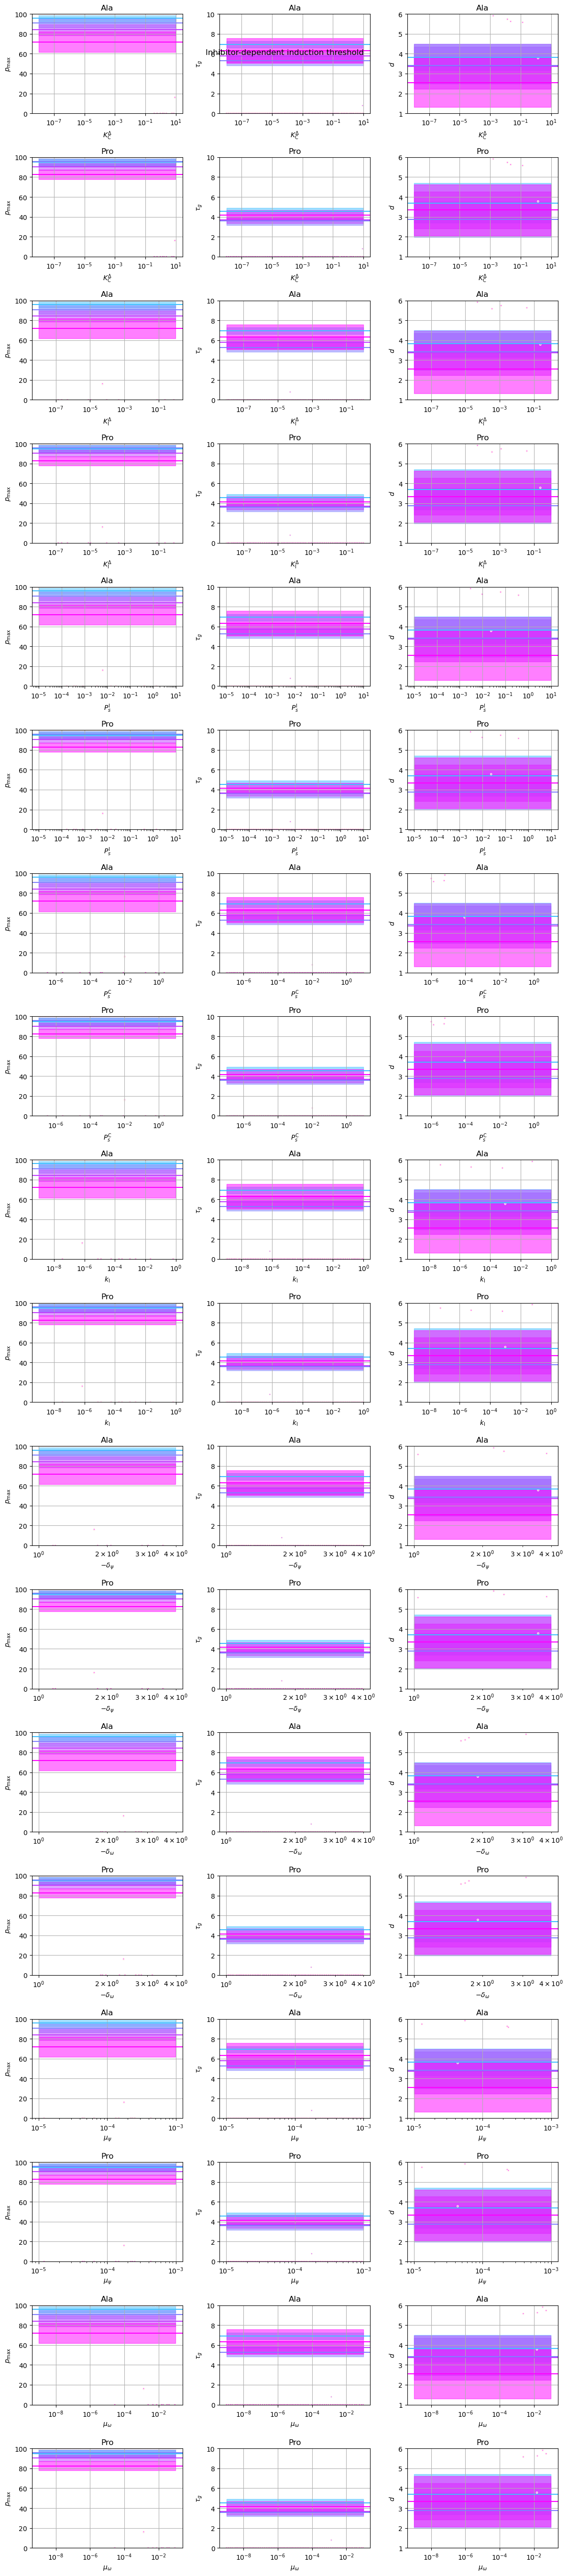

In [ ]:
# Load the fitted parameters
sources, densities, param_dists_rel, param_dists_abs, p_maxs, taus, nus, rmses = jldopen("../src/Data/prior_predictive_checks.jld2", "r") do file
    return file["sources"], file["densities"], file["param_dists_rel"], file["param_dists_abs"], file["p_maxs"], file["taus"], file["nus"], file["rmses"]
end

# Load models and lab data
aliases, combination_IDs, descriptions, param_key_sets = load_model_collection()
df_germination_rebuilt = parse_ijadpanahsaravi_data()
df_germination_rebuilt = filter(row -> row[1] != "Arg", df_germination_rebuilt) # Remove "Arg" from the dataset

# Determine relative vs absolute threshold models
aliases_rel = ["0", "B", "Bi"]

# Carbon source independent prior distributions
params_cs_indep = [:b, :Pₛ, :μ_γ, :neg_δ_γ, :μ_ψ, :neg_δ_ψ]

# Re-generate Sobol sample
n_samples = size(p_maxs)[end]

cmap = get_cmap(:cool)
cmap_edges = get_cmap(:Reds)

# LaTeX symbols mapped to parameter names
params_ltx = Dict(
    :s => L"s",
    :b => L"b",
    :Pₛ => L"P_s^{\text{I}}",
    :Pₛ_cs => L"P_s^{\text{C}}",
    :k_C => L"k_{\text{C}}",
    :k_I => L"k_{\text{I}}",
    :K_I => L"K_{\text{I}}",
    :K_cC => L"K_{\text{C}}^{\Delta}",
    :K_cI => L"K_{\text{I}}^{\Delta}",
    :n => L"n",
    :μ_γ => L"\mu_\gamma",
    :σ_γ => L"\sigma_\gamma",
    :neg_δ_γ => L"-\delta_\gamma",
    :μ_ω => L"\mu_\omega",
    :σ_ω => L"\sigma_\omega",
    :neg_δ_ω => L"-\delta_\omega",
    :μ_ψ => L"\mu_\psi",
    :σ_ψ => L"\sigma_\psi",
    :neg_δ_ψ => L"-\delta_\psi",
)

# Dictionary for saving weights per model
weights_dict_global = Dict()
weights_dict_specific = Dict()

# Tempering parameter
temp_param = 0.25 # β = 0.25

# Analyse and visualise mechanistic model params vs Dantigny params
for m in eachindex(aliases) # Iterate over models

    println("Running $(aliases[m])")

    # Generate (normalized) parameter samples
    n_dims = length(param_key_sets[m])
    sobol_pts = QuasiMonteCarlo.sample(n_samples, n_dims, SobolSample())

    # Check if model uses absolute or relative bounds
    if aliases[m] in aliases_rel
        sample_dists = param_dists_rel
    else
        sample_dists = param_dists_abs
    end

    # Create figure
    matplotlib.pyplot.close()
    n_plot_rows = length(sources) * length(param_key_sets[m])
    fig, axs = subplots(n_plot_rows, 3, figsize=(12, 3 * n_plot_rows))

    weights_penalized = Dict()

    # Mahalanobis distances
    z_dist_global = zeros(n_samples)
    z_dist_specific = zeros(length(sources), n_samples)

    for j in eachindex(densities)  # Iterate over densities

        # Find non-identifiable τ_g and ν
        identifiable = .!isnan.(taus[m, j, :])
        taus_valid = taus[m, j, :][identifiable]
        nus_valid = nus[m, j, :][identifiable]
        rmses_valid = rmses[m, j, :][identifiable]

        for i in eachindex(sources) # Iterate over sources

            data_row = filter(row -> row[1] == sources[i] && row[2] == densities[j], df_germination_rebuilt)[1, :]

            # Half-CIs
            Δ_dantigny = zeros(3)
            Δ_dantigny[1] = (data_row["Pmax_CI_Upper"] - data_row["Pmax_CI_Lower"]) * 0.005
            Δ_dantigny[2] = (data_row["tau_CI_Upper"] - data_row["tau_CI_Lower"]) * 0.5
            Δ_dantigny[3] = (data_row["d_CI_Upper"] - data_row["d_CI_Lower"]) * 0.5

            # Standard deviation and covariance matrix
            σ_dantigny = [Δ/1.96 for Δ in Δ_dantigny]
            Σ = diagm(σ_dantigny .^ 2)

            # Compute differences to experimental data
            diffs_dantigny = zeros(3, n_samples)
            diffs_dantigny[1, :] .= p_maxs[m, j, :] .- data_row["Pmax"] * 0.01
            diffs_dantigny[2, :][identifiable] .= taus_valid .- data_row["tau"]
            diffs_dantigny[3, :][identifiable] .= nus_valid .- data_row["d"]

            # Compute running z's
            for n in 1:n_samples
                if identifiable[n]
                    z_dist_specific[i, n] += dot(diffs_dantigny[:, n], Σ \ diffs_dantigny[:, n])
                else
                    z_dist_specific[i, n] += diffs_dantigny[1, n] .^ 2 / σ_dantigny[1] .^ 2
                end
                z_dist_global[n] += z_dist_specific[i, n]
            end

            # Draw data points and empirical Dantigny statistic
            for (k, key) in enumerate(param_key_sets[m]) # Iterate over parameters

                sample_params = quantile.(sample_dists[key], 0.025 .+ 0.95 .* sobol_pts[k, :]) # limit to sampling to 95% within bounds
                sample_params_valid = sample_params[identifiable]

                axs[(k - 1) * length(sources) + i, 1].axhline(y=data_row["Pmax"], color=cmap(j/length(densities)))
                axs[(k - 1) * length(sources) + i, 1].fill_between([minimum(sample_params), maximum(sample_params)], fill(data_row["Pmax_CI_Lower"], 2), fill(data_row["Pmax_CI_Upper"], 2), color=cmap(j/length(densities)), alpha = 0.5)
                axs[(k - 1) * length(sources) + i, 1].scatter(sample_params, p_maxs[m, j, :] .* 100, s=5, color=cmap(j/length(densities)), linewidths=1, edgecolors=cmap_edges.(rmses[m, j, :]./0.2))
                axs[(k - 1) * length(sources) + i, 1].set_title(sources[i])
                axs[(k - 1) * length(sources) + i, 1].set_ylim(0, 100)
                axs[(k - 1) * length(sources) + i, 1].set_xlabel(params_ltx[key])
                axs[(k - 1) * length(sources) + i, 1].set_ylabel(L"p_{\text{max}}")
                axs[(k - 1) * length(sources) + i, 1].grid(true)
                axs[(k - 1) * length(sources) + i, 1].set_xscale("log")

                axs[(k - 1) * length(sources) + i, 2].axhline(y=data_row["tau"], color=cmap(j/length(densities)))
                axs[(k - 1) * length(sources) + i, 2].fill_between([minimum(sample_params), maximum(sample_params)], fill(data_row["tau_CI_Lower"], 2), fill(data_row["tau_CI_Upper"], 2), color=cmap(j/length(densities)), alpha = 0.5)
                axs[(k - 1) * length(sources) + i, 2].scatter(sample_params_valid, taus_valid, s=5, color=cmap(j/length(densities)), linewidths=1, edgecolors=cmap_edges.(rmses_valid./0.2))
                axs[(k - 1) * length(sources) + i, 2].set_title(sources[i])
                axs[(k - 1) * length(sources) + i, 2].set_ylim(0, 10)
                axs[(k - 1) * length(sources) + i, 2].set_xlabel(params_ltx[key])
                axs[(k - 1) * length(sources) + i, 2].set_ylabel(L"\tau_g")
                axs[(k - 1) * length(sources) + i, 2].grid(true)
                axs[(k - 1) * length(sources) + i, 2].set_xscale("log")

                axs[(k - 1) * length(sources) + i, 3].axhline(y=data_row["d"], color=cmap(j/length(densities)))
                axs[(k - 1) * length(sources) + i, 3].fill_between([minimum(sample_params), maximum(sample_params)], fill(data_row["d_CI_Lower"], 2), fill(data_row["d_CI_Upper"], 2), color=cmap(j/length(densities)), alpha = 0.5)
                axs[(k - 1) * length(sources) + i, 3].scatter(sample_params_valid, nus_valid, s=5, color=cmap(j/length(densities)), linewidths=1, edgecolors=cmap_edges.(rmses_valid./0.2))
                axs[(k - 1) * length(sources) + i, 3].set_title(sources[i])
                axs[(k - 1) * length(sources) + i, 3].set_ylim(1, 6)
                axs[(k - 1) * length(sources) + i, 3].set_xlabel(params_ltx[key])
                axs[(k - 1) * length(sources) + i, 3].set_ylabel(L"d")
                axs[(k - 1) * length(sources) + i, 3].grid(true)
                axs[(k - 1) * length(sources) + i, 3].set_xscale("log")
            end
        end
    end

    # Penalize weights due to RMSE
    reliabilities = exp.(-0.5 .* mean(rmses[m, :, :].^2, dims=1) ./ 0.004) # using an error scale of 2%

    weights_global = exp.(-temp_param .* z_dist_global)
    weights_global_penalized = weights_global .* dropdims(reliabilities; dims=1)
    weights_dict_global[aliases[m]] = weights_global_penalized

    weights_specific = exp.(-temp_param .* z_dist_specific)
    weights_specific_penalized = weights_specific .* repeat(reliabilities; outer=[length(sources), 1])
    weights_dict_specific[aliases[m]] = weights_specific_penalized

    fig.tight_layout()
    fig.suptitle(descriptions[m])
    fig.savefig("ppc_model_$(aliases[m])")

end

jldsave("../src/Data/prior_weights.jld2"; w_global=weights_dict_global, w_specific=weights_dict_specific)

The calibrated prior distributions can be inspected below, querying the weights for each separate model and reconstructing the priors using **Gaussian copula** - a smooth multivariate cumulative distribution function that captures the dependence between parameters. To this end, the parameter samples $\theta_j$ are first mapped to a uniform variable

$$
u_j=F_j{(\theta_j)} \in (0, 1)
$$

(where $F_j$ is the CDF of the marginal prior for the parameter $\theta_j$), which then is transofrmed into Gaussian space by

$$
z_j=\Phi^{-1{(u_j)}}.
$$

A covariance matrix $\Sigma$ is then constructed as

$$
\Sigma=\sum_{s=1}^N{\bar{w}^{(s)}(\mathbf{z}^{(s)}-\mathbf{\mu})(\mathbf{z}^{(s)}-\mathbf{\mu})^\top},
$$

where $\mathbf{\mu}=\sum_{s=1}^N{\bar{w}^{(s)}\mathbf{z}^{(s)}}$ is the mean vector of the weighted transformed samples and $\bar{w}^{(s)}$ are normalized weights.

Constructing a multivariate Gaussian distribution from this, a new sample $\mathbf{z}\sim\mathcal{N}{(\mathbb{E}{[\mathbf{z}^{(s)}-\mathbf{\mu}]_s},\Sigma)}$ can be taken and transformed back to parameter values:

$$
\theta_j=F_j^{-1}{(\Phi{(z_j)})}.
$$

Attempting near-PD projection
Attempting near-PD projection


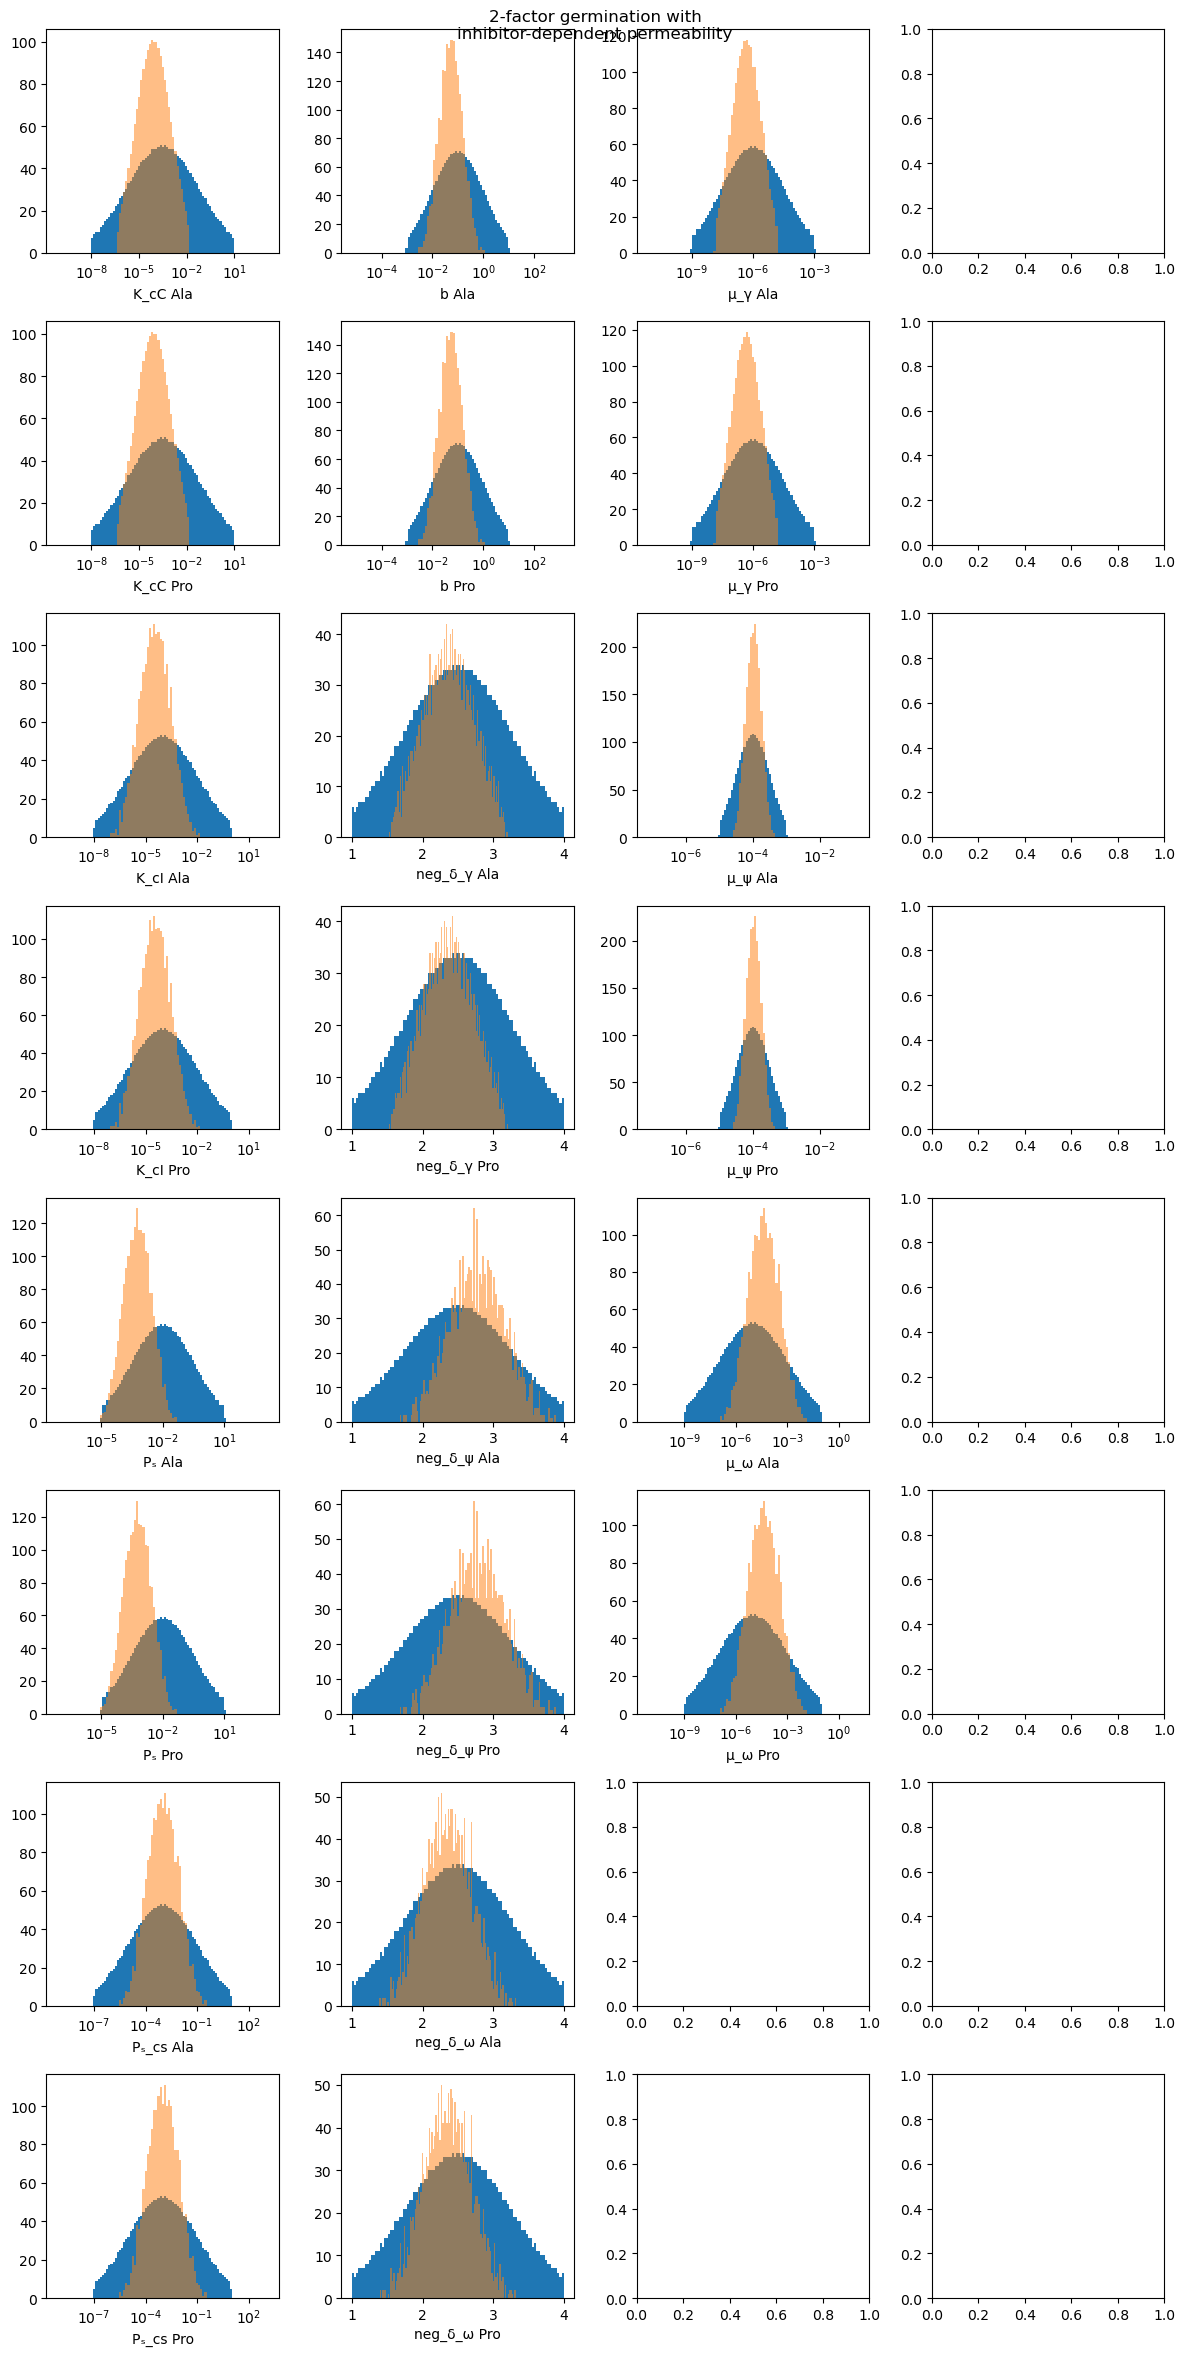

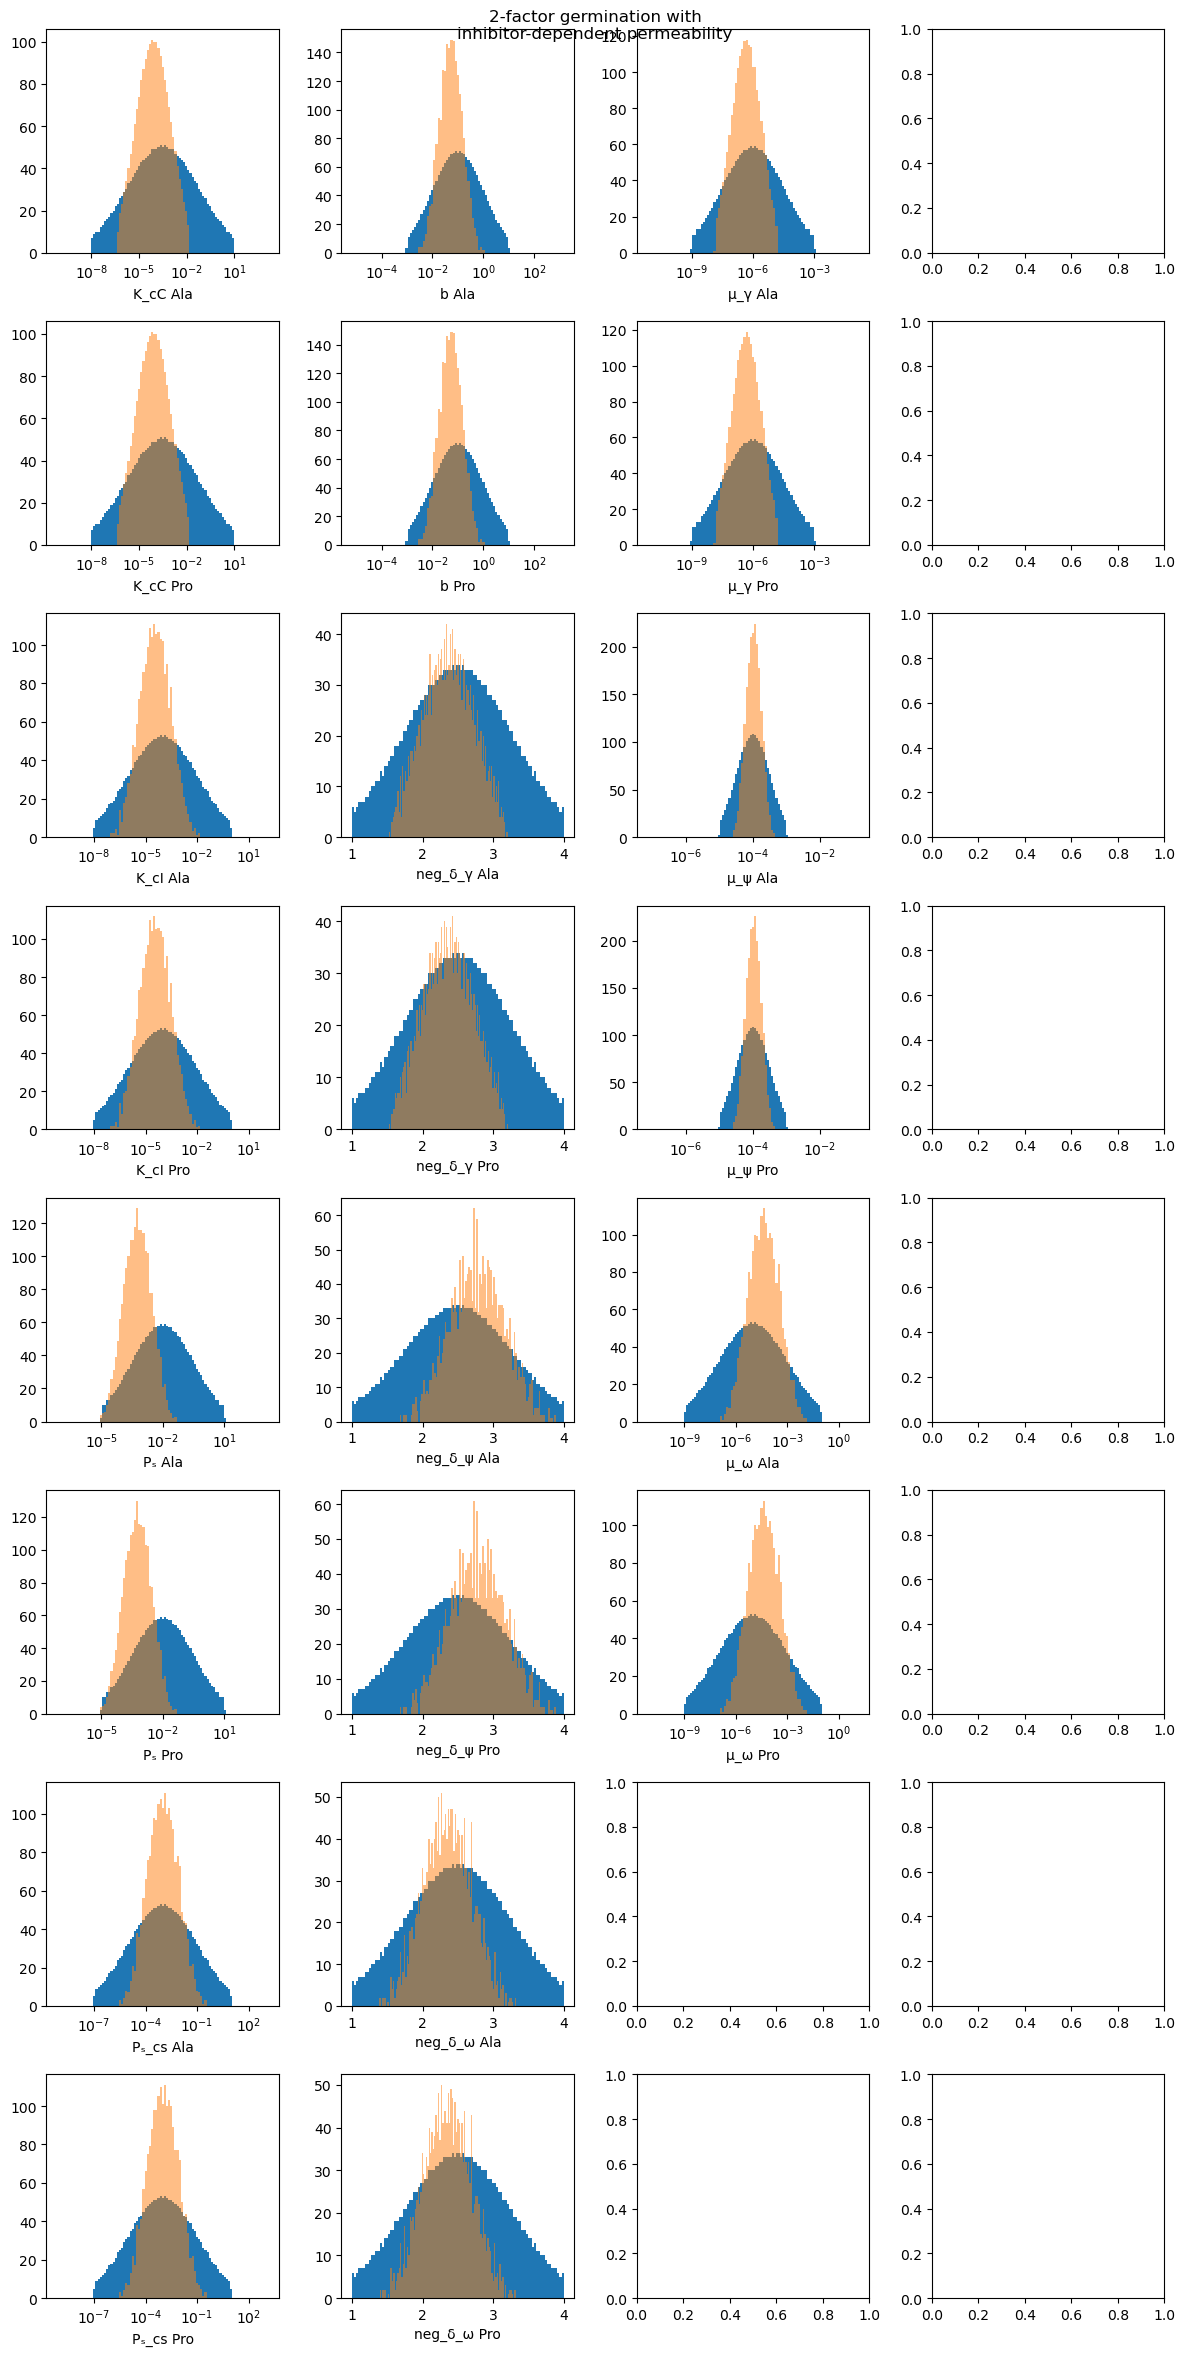

In [33]:
# Load the fitted parameters
sources, densities, param_dists_rel, param_dists_abs, p_maxs, taus, nus, rmses = jldopen("../src/Data/prior_predictive_checks.jld2", "r") do file
    return file["sources"], file["densities"], file["param_dists_rel"], file["param_dists_abs"], file["p_maxs"], file["taus"], file["nus"], file["rmses"]
end

# Load weights
query_model = "feedback_combined_inhibitor_perm"
w_glob = load("../src/Data/prior_weights.jld2", "w_global")[query_model]
# w_glob = ones(size(w_glob))
w_spec = load("../src/Data/prior_weights.jld2", "w_specific")[query_model]
# w_glow_specb = ones(size(w_spec))

# Generate (normalized) parameter samples
aliases, combination_IDs, descriptions, param_key_sets = load_model_collection()
model_idx = findfirst(==(query_model), aliases)
n_samples = length(w_glob)
n_dims = length(param_key_sets[model_idx])
sobol_pts = QuasiMonteCarlo.sample(n_samples, n_dims, SobolSample())

# Shrink samples to 95%
sobol_pts = 0.025 .+ 0.95 .* sobol_pts

# Determine type of distribution
aliases_rel = ["0", "B", "Bi"]
if aliases[model_idx] in aliases_rel
    sample_dists = param_dists_rel
else
    sample_dists = param_dists_abs
end

# Split carbon source independent prior distributions
params_glob_keys = [:b, :Pₛ, :μ_γ, :neg_δ_γ, :μ_ψ, :neg_δ_ψ]
glob_tag = [key in params_glob_keys for key in param_key_sets[model_idx]]
sobol_glob = sobol_pts[glob_tag, :]
sobol_spec = sobol_pts[.!glob_tag, :]

θ_glob = zeros(size(sobol_glob))
θ_spec = zeros(size(sobol_spec))
dists_glob = Vector{Distribution}(undef, size(sobol_glob, 1))
dists_spec = Vector{Distribution}(undef, size(sobol_spec, 1))
g_ct = 1
s_ct = 1
for key in param_key_sets[model_idx]
    if key in params_glob_keys
        θ_glob[g_ct, :] .= quantile.(sample_dists[key], sobol_glob[g_ct, :])
        dists_glob[g_ct] = sample_dists[key]
        g_ct += 1
    else
        θ_spec[s_ct, :] .= quantile.(sample_dists[key], sobol_spec[s_ct, :])
        dists_spec[s_ct] = sample_dists[key]
        s_ct += 1
    end
end

matplotlib.pyplot.close()

fig, axs = subplots(8, 4, figsize=(12, 24))
axs = vec(axs)

# Resample
marg_glob = calibrate_marginals(dists_glob, θ_glob, w_glob)
for (i, src) in enumerate(sources)

    marg_spec = calibrate_marginals(dists_spec, θ_spec, w_glob, w_spec[i, :])
    copula = calibrate_copula(θ_glob, θ_spec, marg_glob, marg_spec, w_glob, w_spec[i, :])
    
    marginals = Vector{Distribution}(undef, n_dims)
    marginals[glob_tag] .= marg_glob
    marginals[.!glob_tag] .= marg_spec

    # println(marginals)

    θ = sample_parameters(sobol_pts, copula, marginals)

    # Save new samples
    for (k, key) in enumerate(param_key_sets[model_idx])
        # if key in params_glob_keys
        #     data = θ_glob_new[g_ct, :]
        #     g_ct += 1
        # else
        #     data = θ_spec_new[s_ct, :]
        #     s_ct += 1
        # end
        data = θ[k, :]
        data_old = quantile(sample_dists[key], sobol_pts[k, :])

        # Log bins
        if startswith(string(key), "neg_δ_")
            axs[(k-1)*length(sources) + i].hist(data_old, bins=100)
            axs[(k-1)*length(sources) + i].hist(data, bins=100, alpha=0.5)
        else
            bins = exp.(LinRange(log(minimum(data_old))-5, log(maximum(data_old))+5, 100))
            axs[(k-1)*length(sources) + i].hist(data_old, bins=bins)
            axs[(k-1)*length(sources) + i].hist(data, bins=bins, alpha=0.5)
            axs[(k-1)*length(sources) + i].set_xscale("log")
        end

        axs[(k-1)*length(sources) + i].set_xlabel(string(key) * " " * src)
    end
end

fig.suptitle(descriptions[model_idx])

tight_layout()
gcf()

This procedure clearly narrows down the priors, but for a more robust calibration a few checks need to be performed, and multiple iterations executed to exhibit convergence of the parameter distributions.

The following criteria determine a prior as well-calibrated:

**_1. The Dantigny summaries from the calibrated priors should cover the lab summary CIs well enough, but not too tightly:_**

For each experimental condition $c$ and each Dantigny parameter $d$, given the confidence intervals $[L_d, U_d]$ from the lab experiments, the fraction of newly derived Dantigny values $p_d$ included in the CI,

$$
\pi_{d,c}=\mathbb{P}_{\textrm{prior}}{(p_d\in[L_d, U_d])},
$$

should be within a reasonable range. For the current purposes, the goal is $\pi_{d,c}\in[0.2, 0.8]$.

**_2. The lab means should not be outliers in the prior distributions:_**

Computing the prior predictive quantile of the lab mean $\mu_d^{\textrm{lab}}$,

$$
q_{d,c}=F_{\textrm{prior}}{(\mu_d^{\textrm{lab}})},
$$

should yield $q_{d,c}\in[0.1, 0.9]$.

**_3. The joint lab mean should lie within 95% joint predictive region:_**

The marginal inclusion does not suffice to guarantee that a point is still within the joint probability region of the priors. Therefore, considering the vectors

$$
\mathbf{p}^{(s)}=\left(p_{\max}^{(s)}, \tau_g^{(s)}, \nu^{(s)}\right)
$$

and computing their mean $\mathbf{\mu}_{\textrm{prior}}$ and predictive covariance $\Sigma_{\textrm{prior}}$, the Mahalanobis distance between the predictive and lab means can be computed:

$$
D^2=\left(\mathbf{p}_{\textrm{lab}}-\mathbf{\mu}_{\textrm{prior}}\right)^\top\Sigma_{\textrm{prior}}^{-1}\left(\mathbf{p}_{\textrm{lab}}-\mathbf{\mu}_{\textrm{prior}}\right).
$$

It is to be asserted that this measure lies below a $\chi^2$ threshold corresponding to 95% confidence level and 3 degrees of freedom (matching the 3 Dantigny parameters):

$$
D^2<\chi^2_{3, 0.95}\approx 7.815.
$$

**_4. The prior predictive width should be larger than the lab uncertainty:_**

This is tested by comparing the interquartile range (IQR) of the predictive Dantigny summaries to the respective CI of the lab results ($\textrm{IQR}>\textrm{CI}$).

**_5. Key diagnostics should remain stable under resampling:_**

When shuffling the Sobol samples across parameters, the following diagnostics should change by less than 10%:
- the fraction of lab means inside the marginal intervals ($\pi_{d,c}$);
- the fraction of lab means inside the joint regions ($\frac{1}{N}\sum_{s=1}^N{\mathbb{I}{[z^{(s)}\le\chi^2_{3,0.95}]}}$);
- the prior predictive IQRs;
- the mean and variance of the weights $w_s'$.

**_6. Every model should assign non-negligible prior predictive probability to the lab observations:_**

In other words, the probability of a prior summary to appear within the bounds of the lab CIs should be larger than a threshold value $\varepsilon = 10^{-2}$.

These criteria are integrated in the following procedure:

1. Initial prior guesses are established.
2. The priors are sampled using Sobol sequences for each mechanistic model.
3. Dantigny summaries are fit to the results of each mechanistic model.
4. Success criteria are evaluated:
    - Criteria 4-6 must hold;
    - The measures for criteria 1-3 should hold or have changed by less than 10% in the last 5 iterations.
6. If the success criteria are met, the process terminates; otherwise, the priors are recalibrated and steps 2.-6. are repeated.

In [ ]:
example_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05,
    :Pₛ => 1e-3,
    :Pₛ_cs => 1e-6,
    :μ_γ => 1e-3,
    :σ_γ => 1e-4,
    :μ_ω => 1e-1,
    :σ_ω => 1e-2,
    :s => 0.5,
    :b => 0.95,
    :μ_ψ => 0.5,
    :σ_ψ => 0.01,
    :K_cC => 0.01,
    :K_cI => 0.01,
    :K_I => 0.01,
    :k_C => 0.1,
    :n => 2,
    :k_I => 1.0
)

In [29]:
anchor = Dict(
    :Pₛ => 1e-3,
    :Pₛ_cs => 1e-6,
    :μ_γ => 1e-3,
    :neg_δ_γ => 1,
    :μ_ω => 1e-1,
    :neg_δ_ω => 1,
    :s => 0.5,
    :b => 0.95,
    :μ_ψ => 0.5,
    :σ_ψ => 0.01,
    :K_cC => 0.01,
    :K_cI => 0.01,
    :K_I => 0.01,
    :k_C => 0.1,
    :n => 2,
    :k_I => 1.0
)

# Default parameters
def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)

sensitivity_analysis(def_params, bounds_abs, bounds_rel, anchor)

Running independent
K_cC: lower = -18.420680743952367 / lower (sweep) = -6.605170185988091 / anchor = -4.605170185988091 / upper (sweep) = -2.6051701859880914 / upper = 2.302585092994046
Pₛ: lower = -11.512925464970229 / lower (sweep) = -8.907755278982137 / anchor = -6.907755278982137 / upper (sweep) = -4.907755278982137 / upper = 2.302585092994046
Pₛ_cs: lower = -16.11809565095832 / lower (sweep) = -15.815510557964274 / anchor = -13.815510557964274 / upper (sweep) = -11.815510557964274 / upper = 2.302585092994046
neg_δ_γ: lower = 0 / lower (sweep) = 0.1353352832366127 / anchor = 1.0 / upper (sweep) = 4.0 / upper = 4
neg_δ_ω: lower = 0 / lower (sweep) = 0.1353352832366127 / anchor = 1.0 / upper (sweep) = 4.0 / upper = 4
μ_γ: lower = -13.815510557964274 / lower (sweep) = -8.907755278982137 / anchor = -6.907755278982137 / upper (sweep) = -4.907755278982137 / upper = 0.0
μ_ω: lower = -20.72326583694641 / lower (sweep) = -4.302585092994046 / anchor = -2.3025850929940455 / upper (sweep) = -

In [ ]:
n_samples = 8192#256#4096#2048

# Maximum number of calibration iterations
n_iter = 20

# Default parameters
def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)

# data_pts_dict = calibrate_priors(n_iter, n_samples, def_params, bounds_abs, bounds_rel)
calibrate_priors(n_iter, n_samples, def_params, bounds_abs, bounds_rel; use_surrogates=false)

Running independent

===== Iteration 1 =====
Global parameter means: [0.30855084705939484; 2.50000000000001; 3.085508470593948e-5;;]
Specific parameter means: [0.17142020366208177 0.20221636782779412 2.500000000000005 0.0020221636782779347; 0.17142020366208177 0.20221636782779412 2.500000000000005 0.0020221636782779347;;;]
Running mechanistic model on 8192 samples (100.0%)

---- Running model independent with density 33333.333333333336 and source Ala -----
8192 valid Dantigny summaries
Mean p_max: 0.4334583846185305 (1.4499267933336945e-65 - 1.0, 0 NaNs)
Mean tau_g: Inf (2.671163568265632e-307 - 1.7972315839931962e308, 0 NaNs)
Mean nu: Inf (1.1133811919807883e-18 - Inf, 0 NaNs)
Mechanistic model uncertainties range from [0.0; 0.0; 0.0;;] to [2.2067673864263338e23; 1.1558887682883572e46; 1.8689422433095598e44;;]
Invalid uncertainties: 0
5373 summaries in bounds & full

---- Running model independent with density 33333.333333333336 and source Pro -----
8192 valid Dantigny summaries
Mean 

In [6]:
debug_vals, data_pts_dict = jldopen("../src/Data/priors.jld2", "r") do file
    return file["debug_vals"], file["data_pts_dict"]
end

data_pts = data_pts_dict["independent"]

query_iter = 2
query_src = 1
query_dens = 1

n_samples = size(debug_vals[:d], 4)

println("Querying iteration $query_iter, density $query_dens and source $query_src:")

for n in 1:n_samples
    d = debug_vals[:d][query_iter, query_dens, query_src, n, :]
    d_alt = debug_vals[:d_alt][query_iter, query_dens, query_src, :, n]
    lab_means = debug_vals[:lab_means][query_iter, query_dens, query_src, n, :]
    diffs = debug_vals[:diffs][query_iter, query_dens, query_src, n, :]
    z_dist = debug_vals[:z_dist][query_iter, query_dens, query_src, n]
    w_spec = debug_vals[:w_spec][query_iter, query_src, n]
    # params = debug_vals[:params][query_iter, query_src, :, n]
    penalty = debug_vals[:penalties][query_iter, query_dens, query_src, n]
    println("$n: Summary $d has weight $w_spec, due to z_dist $z_dist based on differences $diffs from lab means $lab_means (penalty $penalty)")
    # println("Data point $(data_pts[query_src, query_iter, :, n])")
end

Querying iteration 2, density 1 and source 1:
1: Summary [1.6816169768067216e-7, 412.7280537837637, 0.9442782732486659] has weight 4.6896178731827626e-307, due to z_dist 3349.4543617392496 based on differences [-0.9597998318383024, 405.7980537837637, -2.885721726751334] from lab means [0.9598000000000001, 6.93, 3.83] (penalty 0.0)
2: Summary [0.9669992020103343, 1.1987632450403385e-56, 4.116281269468406e-11] has weight 0.0, due to z_dist 1.0e8 based on differences [0.0, 0.0, 0.0] from lab means [0.0, 0.0, 0.0] (penalty 0.0)
3: Summary [0.99988546532968, 2.439638042849573, 14.213115325609031] has weight 0.3981805396220647, due to z_dist 1610.7016665768099 based on differences [0.04008546532967994, -4.4903619571504265, 10.383115325609031] from lab means [0.9598000000000001, 6.93, 3.83] (penalty 0.0)
4: Summary [2.450537007415876e-7, 702.0261347848908, 0.9076371077394632] has weight 0.0, due to z_dist 4583.168719368776 based on differences [-0.9597997549462993, 695.0961347848909, -2.92236

[1.1328308913541191e-37, 3.720075976020836e-44, 0.9210938414335362, 0.8533002574038018, 0.8709366461089353, 1.1328308874860692e-37, 0.8206200910629486, 4.870065941678042e-16, 1.8869201262083132e-12, 2.4921380818348623e-33, 0.8946577774778353, 1.13283067478345e-37, 0.8832820735577279, 5.955679476218631e-31, 4.559103256566682e-16, 1.1328308902543504e-37, 1.8796080781718276e-22, 4.5953958552466905e-27, 1.2067700213367937e-11, 7.648422962515408e-27, 1.8111722787200245e-22, 1.8584648166383227e-28, 2.6136073010381067e-33, 7.49193085416541e-27, 1.1328308907440021e-37, 2.5524032061252744e-41, 1.1328308911876284e-37, 6.2028613228201966e-27, 1.8607618237983644e-22, 1.1962080225625983e-11, 1.132830859895229e-37, 1.334635716013137e-11, 0.8330667945012844, 1.781323794572339e-22, 5.023999395715152e-16, 1.7823902172116724e-22, 0.07516396902018052, 7.095361411861397e-27, 2.0732789544861325e-32, 1.8764608217296477e-22, 3.7882377521353165e-16, 1.8257723720409867e-22, 7.255562035026411e-27, 1.88946833258

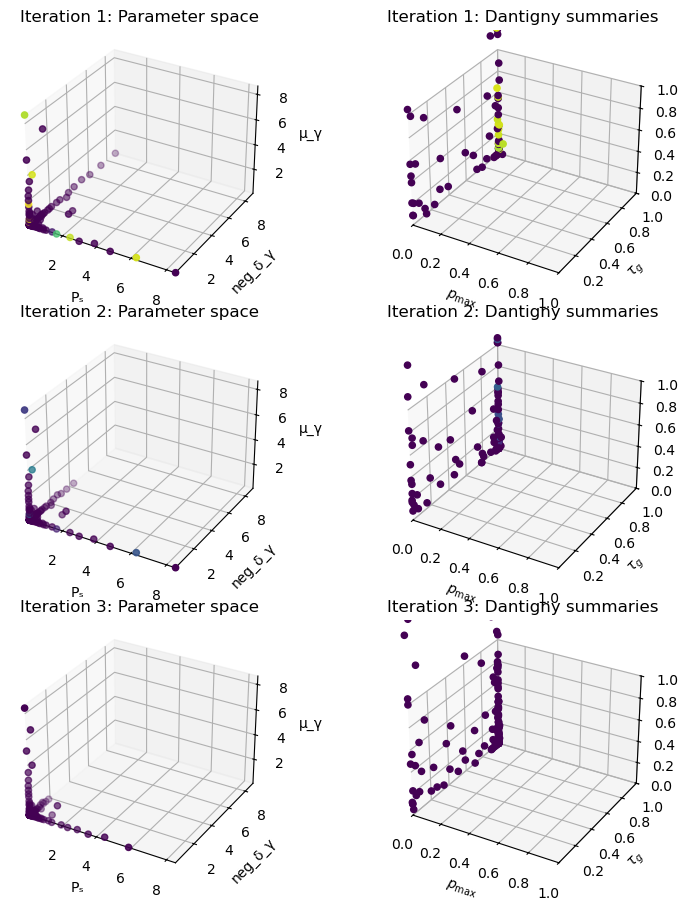

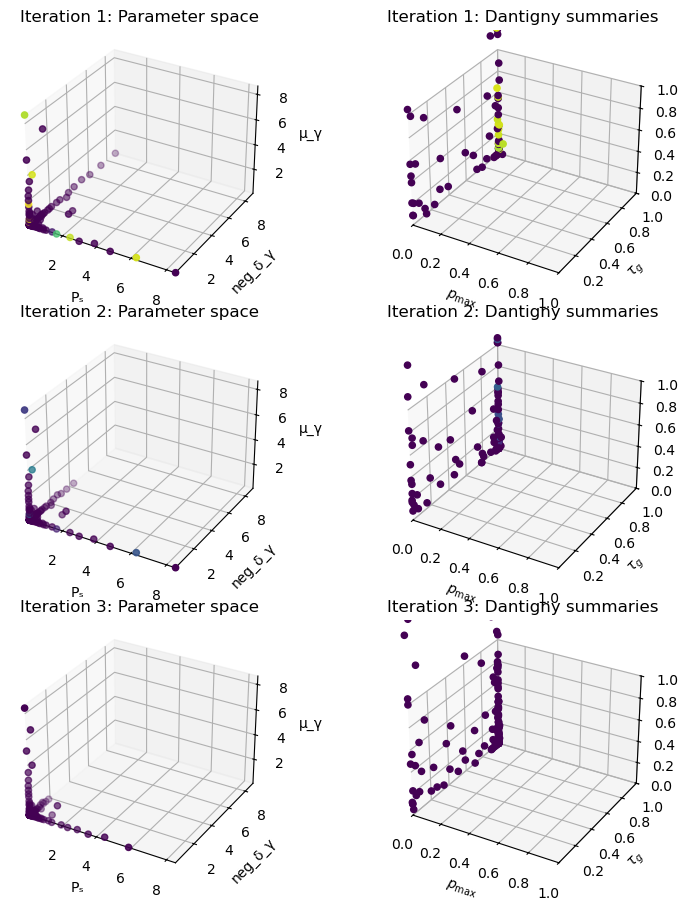

In [6]:
# Load the data points
param_vals, dantigny_vals, weights = jldopen("../src/Data/priors.jld2", "r") do file
    data_pts = file["data_pts_dict"]["independent"]
    weights = file["w_spec_record_all"]["independent"]
    return data_pts[:, :, 1:3, :], data_pts[:, :, (end - 3):end, :], weights
end

println(unique(weights[1, 1, :]))

# println(size(param_vals))
# println(size(dantigny_vals))
# println(size(weights))

plot_prior_calibration(param_vals, dantigny_vals, [:Pₛ, :neg_δ_γ, :μ_γ], weights; query_pt_idx=1)

Smoothing radius: 18
(1.0, 1.7417417417417416, 12.464353969616978)


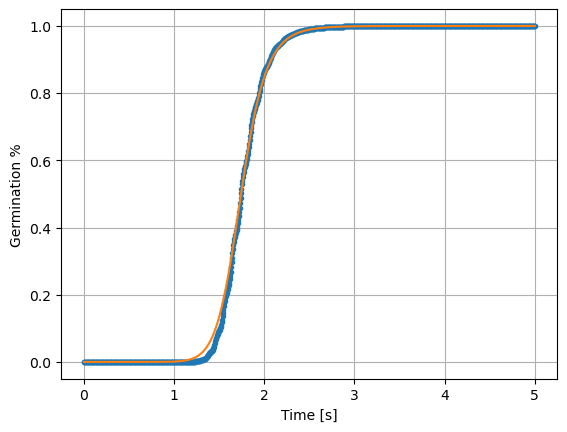

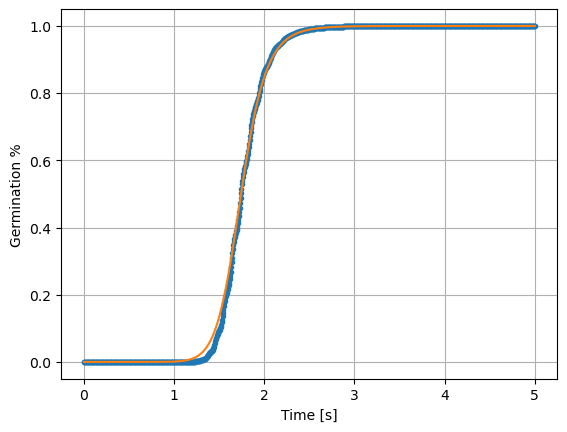

In [28]:
# example_params = Dict(
#     :μ_ξ => 2.65,
#     :σ_ξ => 0.3,
#     :c₀_cs => 0.01,
#     :d_hp => 0.01,
#     :μ_κ => 0.2,
#     :σ_κ => 0.05,
#     :Pₛ => 1e-3,
#     :Pₛ_cs => 1e-5,
#     :μ_γ => 1e-3,
#     :σ_γ => 1e-3,
#     :μ_ω => 1e-3,
#     :σ_ω => 1e-3,
#     :s => 0.5,
#     :b => 0.95,
#     :μ_ψ => 0.5,
#     :σ_ψ => 0.01,
#     :K_cC => 0.01,
#     :K_cI => 0.01,
#     :K_I => 0.01,
#     :k_C => 0.1,
#     :n => 2,
#     :k_I => 1.0
# )

example_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05,
    :Pₛ => 1e-3,
    :Pₛ_cs => 1e-6,
    :μ_γ => 1e-3,
    :σ_γ => 1e-4,
    :μ_ω => 1e-1,
    :σ_ω => 1e-2,
    :s => 0.5,
    :b => 0.95,
    :μ_ψ => 0.5,
    :σ_ψ => 0.01,
    :K_cC => 0.01,
    :K_cI => 0.01,
    :K_I => 0.01,
    :k_C => 0.1,
    :n => 2,
    :k_I => 1.0
)

matplotlib.pyplot.close()

t_max_eval = 5
times_eval = LinRange(0, t_max_eval, 1000)
density_test = inverse_mL_to_cubic_um(125000)

p_out = compute_germination_response("independent", times_eval .* 3600, density_test, example_params)

d_infer = infer_dantigny_parameters(p_out, times_eval)
println(d_infer)

p_dantigny = dantigny.(times_eval, d_infer...)

fig, ax = subplots()

ax.plot(times_eval, p_out, marker=".")
ax.plot(times_eval, p_dantigny)

# ax.plot([0, 2*d_infer[1]], )
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
# ax.set_xlim(5000, 7500)
# ax.set_ylim(0.4, 0.6)
gcf()

In [10]:
# Debugging
matplotlib.pyplot.close()

data_pts = data_pts_dict[1]
param_keys = param_key_sets[1]

n_src = size(data_pts, 1)
n_steps = size(data_pts, 2)
n_dims = size(data_pts, 3) - 3
n_samples = size(data_pts, 4)

fig, axs = subplots(n_dims*n_src, 3, figsize=(12, 8*n_dims))
cmap = get_cmap(:plasma)

dantigny_params = [L"p_{\max}", L"\tau_g", L"\nu"]

for i in 1:n_src
    for j in 1:n_steps
        for k in 1:n_dims
            for n in 1:3
                axs[(k - 1)*n_src + i, n].scatter(data_pts[i, j, k, :], data_pts[i, j, n_dims + n, :], color=cmap(j/n_steps), alpha=0.5)
                axs[(k - 1)*n_src + i, n].set_xlabel(param_keys[k])
                axs[(k - 1)*n_src + i, n].set_ylabel(dantigny_params[n])
                axs[(k - 1)*n_src + i, n].grid(true)
                axs[(k - 1)*n_src + i, n].set_xscale(:log)
                axs[(k - 1)*n_src + i, n].set_ylim(0, maximum(CIs[:, i, n, 2])*1.5)
                
                for p in 1:n_dens
                    axs[(k - 1)*n_src + i, n].fill_between([minimum(data_pts[i, :, k, :]), maximum(data_pts[i, :, k, :])], [CIs[p, i, n, 1], CIs[p, i, n, 1]], [CIs[p, i, n, 2], CIs[p, i, n, 2]], color=:lightblue, alpha=0.1)
                    # axs[(k - 1)*n_src + i, n].axhline(CIs[p, i, n, 2], color=:blue)
                    axs[(k - 1)*n_src + i, n].axhline(lab_means[p, i, n], color=:red)
                end
            end
        end
    end
end

tight_layout()
gcf()

LoadError: UndefVarError: `data_pts_dict` not defined

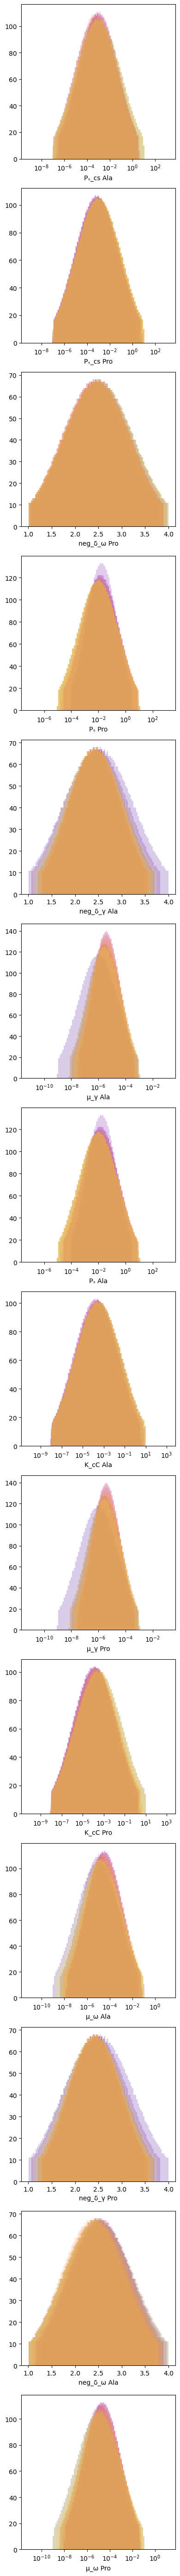

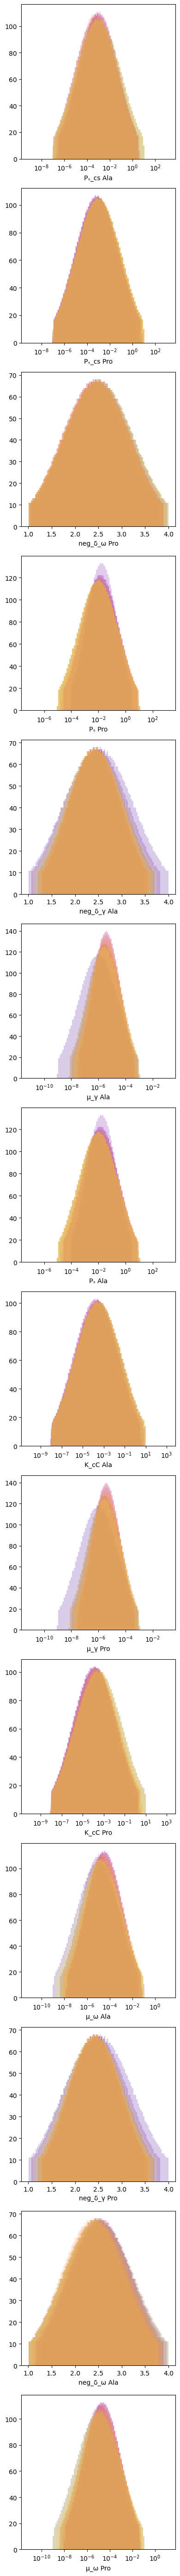

In [22]:
# Debugging
matplotlib.pyplot.close()

aliases, combination_IDs, descriptions, param_key_sets = load_model_collection()
priors_all = load("../src/Data/priors.jld2", "priors_all")

alias_current = "independent"

priors_running = [
    Dict{Any, Any}(Symbol("Pₛ Pro") => LogNormal{Float64}(-4.605170185988092, 3.524364938256192), Symbol("neg_δ_γ Ala") => Normal{Float64}(2.5, 0.7653061224489796), Symbol("K_cC Ala") => LogNormal{Float64}(-8.05904782547916, 5.2865474073842895), Symbol("μ_γ Pro") => LogNormal{Float64}(-13.815510557964274, 3.524364938256192), Symbol("μ_ω Ala") => LogNormal{Float64}(-11.512925464970229, 4.699153251008256), Symbol("neg_δ_ω Ala") => Normal{Float64}(2.5, 0.7653061224489796), Symbol("μ_ω Pro") => LogNormal{Float64}(-11.512925464970229, 4.699153251008256), Symbol("Pₛ_cs Ala") => LogNormal{Float64}(-6.907755278982137, 4.699153251008257), Symbol("Pₛ_cs Pro") => LogNormal{Float64}(-6.907755278982137, 4.699153251008257), Symbol("neg_δ_ω Pro") => Normal{Float64}(2.5, 0.7653061224489796), Symbol("μ_γ Ala") => LogNormal{Float64}(-13.815510557964274, 3.524364938256192), Symbol("Pₛ Ala") => LogNormal{Float64}(-4.605170185988092, 3.524364938256192), Symbol("K_cC Pro") => LogNormal{Float64}(-8.05904782547916, 5.2865474073842895), Symbol("neg_δ_γ Pro") => Normal{Float64}(2.5, 0.7653061224489796)),
    Dict{Any, Any}(Symbol("Pₛ Pro") => LogNormal{Float64}(-4.065944738492611, 2.6806383902312296), Symbol("neg_δ_γ Ala") => Normal{Float64}(2.4460777932646196, 0.7038747296979828), Symbol("K_cC Ala") => LogNormal{Float64}(-8.217125992824695, 5.205895281187588), Symbol("μ_γ Pro") => LogNormal{Float64}(-12.684167618741965, 2.9142658161025414), Symbol("μ_ω Ala") => LogNormal{Float64}(-11.26348048217022, 4.076657923771919), Symbol("neg_δ_ω Ala") => Normal{Float64}(2.480857723422388, 0.7555396548073409), Symbol("μ_ω Pro") => LogNormal{Float64}(-11.26348048217022, 4.104523939584097), Symbol("Pₛ_cs Ala") => LogNormal{Float64}(-7.381969443229892, 4.457207248841035), Symbol("Pₛ_cs Pro") => LogNormal{Float64}(-7.140060383595343, 4.580630238450499), Symbol("neg_δ_ω Pro") => Normal{Float64}(2.484692994283359, 0.757496425654775), Symbol("μ_γ Ala") => LogNormal{Float64}(-12.684167618741965, 2.9142658161025414), Symbol("Pₛ Ala") => LogNormal{Float64}(-4.065944738492611, 2.6806383902312296), Symbol("K_cC Pro") => LogNormal{Float64}(-8.746411703051015, 4.935851551480282), Symbol("neg_δ_γ Pro") => Normal{Float64}(2.4460777932646196, 0.7038747296979828)),
    Dict{Any, Any}(Symbol("Pₛ Pro") => LogNormal{Float64}(-4.306534546023079, 3.206703497009862), Symbol("neg_δ_γ Ala") => Normal{Float64}(2.4506621485377944, 0.6372656579315517), Symbol("K_cC Ala") => LogNormal{Float64}(-8.60346342155356, 5.008784348162657), Symbol("μ_γ Pro") => LogNormal{Float64}(-12.915227220307724, 2.9672005145782907), Symbol("μ_ω Ala") => LogNormal{Float64}(-10.398602028784806, 3.866151364041339), Symbol("neg_δ_ω Ala") => Normal{Float64}(2.5227931319764814, 0.6998080281480386), Symbol("μ_ω Pro") => LogNormal{Float64}(-10.745466806168613, 3.8934280564186996), Symbol("Pₛ_cs Ala") => LogNormal{Float64}(-7.03023331912671, 4.227493868256339), Symbol("Pₛ_cs Pro") => LogNormal{Float64}(-7.253372852889855, 4.508908358326377), Symbol("neg_δ_ω Pro") => Normal{Float64}(2.4713015587074496, 0.7269043011333199), Symbol("μ_γ Ala") => LogNormal{Float64}(-12.915227220307724, 2.9672005145782907), Symbol("Pₛ Ala") => LogNormal{Float64}(-4.306534546023079, 3.206703497009862), Symbol("K_cC Pro") => LogNormal{Float64}(-8.974148474680945, 4.819659321056848), Symbol("neg_δ_γ Pro") => Normal{Float64}(2.4506621485377944, 0.6372656579315517)),
    Dict{Any, Any}(Symbol("Pₛ Pro") => LogNormal{Float64}(-4.226470412632253, 3.1881222090256713), Symbol("neg_δ_γ Ala") => Normal{Float64}(2.4255252060836976, 0.5745759838317286), Symbol("K_cC Ala") => LogNormal{Float64}(-8.56896831697455, 5.026383891315213), Symbol("μ_γ Pro") => LogNormal{Float64}(-12.445542656323864, 2.4342948628059244), Symbol("μ_ω Ala") => LogNormal{Float64}(-10.255369498293195, 3.8516542045635807), Symbol("neg_δ_ω Ala") => Normal{Float64}(2.5475943734499995, 0.6904809499995503), Symbol("μ_ω Pro") => LogNormal{Float64}(-10.705972837995905, 3.877075582733108), Symbol("Pₛ_cs Ala") => LogNormal{Float64}(-6.862594048801463, 4.079375863628854), Symbol("Pₛ_cs Pro") => LogNormal{Float64}(-7.223283061549033, 4.491933494116919), Symbol("neg_δ_ω Pro") => Normal{Float64}(2.47451643149999, 0.7280999036378222), Symbol("μ_γ Ala") => LogNormal{Float64}(-12.445542656323864, 2.4342948628059244), Symbol("Pₛ Ala") => LogNormal{Float64}(-4.226470412632253, 3.1881222090256713), Symbol("K_cC Pro") => LogNormal{Float64}(-8.89157387340251, 4.861789219668294), Symbol("neg_δ_γ Pro") => Normal{Float64}(2.4255252060836976, 0.5745759838317286)),
    Dict{Any, Any}(Symbol("Pₛ Pro") => LogNormal{Float64}(-4.333599048503658, 3.3269385023432214), Symbol("neg_δ_γ Ala") => Normal{Float64}(2.4263029110441514, 0.5785565790535447), Symbol("K_cC Ala") => LogNormal{Float64}(-8.360462782621422, 5.132764265985176), Symbol("μ_γ Pro") => LogNormal{Float64}(-12.524128830998865, 2.4571621336803857), Symbol("μ_ω Ala") => LogNormal{Float64}(-10.365676253963539, 3.9100626801024774), Symbol("neg_δ_ω Ala") => Normal{Float64}(2.4816420197398683, 0.6899233051024227), Symbol("μ_ω Pro") => LogNormal{Float64}(-10.752338463898838, 3.971315790270451), Symbol("Pₛ_cs Ala") => LogNormal{Float64}(-6.845910056522454, 4.217400750751841), Symbol("Pₛ_cs Pro") => LogNormal{Float64}(-7.055921537444089, 4.623558221180731), Symbol("neg_δ_ω Pro") => Normal{Float64}(2.429360680839615, 0.7292656534895995), Symbol("μ_γ Ala") => LogNormal{Float64}(-12.524128830998865, 2.4571621336803857), Symbol("Pₛ Ala") => LogNormal{Float64}(-4.333599048503658, 3.3269385023432214), Symbol("K_cC Pro") => LogNormal{Float64}(-8.779786167793777, 4.91882376334622), Symbol("neg_δ_γ Pro") => Normal{Float64}(2.4263029110441514, 0.5785565790535447)),
    Dict{Any, Any}(Symbol("Pₛ Pro") => LogNormal{Float64}(-4.459700744341427, 3.450145835375242), Symbol("neg_δ_γ Ala") => Normal{Float64}(2.4264165384861003, 0.5893884175218052), Symbol("K_cC Ala") => LogNormal{Float64}(-8.177174208961842, 5.226278844382921), Symbol("μ_γ Pro") => LogNormal{Float64}(-12.518593227309768, 2.5636034490765423), Symbol("μ_ω Ala") => LogNormal{Float64}(-10.61602410769555, 3.9910032063307175), Symbol("neg_δ_ω Ala") => Normal{Float64}(2.4559452494784075, 0.7027444715531216), Symbol("μ_ω Pro") => LogNormal{Float64}(-10.857732354909007, 4.070270553633256), Symbol("Pₛ_cs Ala") => LogNormal{Float64}(-7.455588129396787, 4.16256981520446), Symbol("Pₛ_cs Pro") => LogNormal{Float64}(-6.98123930242471, 4.661661402313067), Symbol("neg_δ_ω Pro") => Normal{Float64}(2.441818406133052, 0.7356216357821694), Symbol("μ_γ Ala") => LogNormal{Float64}(-12.518593227309768, 2.5636034490765423), Symbol("Pₛ Ala") => LogNormal{Float64}(-4.459700744341427, 3.450145835375242), Symbol("K_cC Pro") => LogNormal{Float64}(-8.654690572923204, 4.98264804644345), Symbol("neg_δ_γ Pro") => Normal{Float64}(2.4264165384861003, 0.5893884175218052)),
    Dict{Any, Any}(Symbol("Pₛ Pro") => LogNormal{Float64}(-4.605170185988092, 3.524364938256192), Symbol("neg_δ_γ Ala") => Normal{Float64}(2.426973926543743, 0.6005107471577623), Symbol("K_cC Ala") => LogNormal{Float64}(-8.05904782547916, 5.2865474073842895), Symbol("μ_γ Pro") => LogNormal{Float64}(-12.51654391628271, 2.6737249768421423), Symbol("μ_ω Ala") => LogNormal{Float64}(-10.733375389425838, 4.0974871276747615), Symbol("neg_δ_ω Ala") => Normal{Float64}(2.3808407011867123, 0.7045105618299553), Symbol("μ_ω Pro") => LogNormal{Float64}(-10.999950266988378, 4.187701129508239), Symbol("Pₛ_cs Ala") => LogNormal{Float64}(-7.431996943041268, 4.340893332672146), Symbol("Pₛ_cs Pro") => LogNormal{Float64}(-6.907755278982137, 4.699153251008257), Symbol("neg_δ_ω Pro") => Normal{Float64}(2.4409264735064795, 0.7351665681155509), Symbol("μ_γ Ala") => LogNormal{Float64}(-12.51654391628271, 2.6737249768421423), Symbol("Pₛ Ala") => LogNormal{Float64}(-4.605170185988092, 3.524364938256192), Symbol("K_cC Pro") => LogNormal{Float64}(-8.468704817648131, 5.0775387379103245), Symbol("neg_δ_γ Pro") => Normal{Float64}(2.426973926543743, 0.6005107471577623)),
    Dict{Any, Any}(Symbol("Pₛ Pro") => LogNormal{Float64}(-4.605170185988092, 3.524364938256192), Symbol("neg_δ_γ Ala") => Normal{Float64}(2.427595045669401, 0.6131470077024598), Symbol("K_cC Ala") => LogNormal{Float64}(-8.234836149185451, 5.196859487125978), Symbol("μ_γ Pro") => LogNormal{Float64}(-12.55912513703994, 2.8059456110391423), Symbol("μ_ω Ala") => LogNormal{Float64}(-10.55147434517174, 4.208616965396783), Symbol("neg_δ_ω Ala") => Normal{Float64}(2.424587949637802, 0.7196226797122863), Symbol("μ_ω Pro") => LogNormal{Float64}(-11.010605498131891, 4.331814106307002), Symbol("Pₛ_cs Ala") => LogNormal{Float64}(-7.240056632868107, 4.529611743923578), Symbol("Pₛ_cs Pro") => LogNormal{Float64}(-6.907755278982137, 4.699153251008257), Symbol("neg_δ_ω Pro") => Normal{Float64}(2.4660491889035123, 0.7479842800528123), Symbol("μ_γ Ala") => LogNormal{Float64}(-12.55912513703994, 2.8059456110391423), Symbol("Pₛ Ala") => LogNormal{Float64}(-4.605170185988092, 3.524364938256192), Symbol("K_cC Pro") => LogNormal{Float64}(-8.48491216779247, 5.069269681714234), Symbol("neg_δ_γ Pro") => Normal{Float64}(2.427595045669401, 0.6131470077024598)),
    Dict{Any, Any}(Symbol("Pₛ Pro") => LogNormal{Float64}(-4.605170185988092, 3.524364938256192), Symbol("neg_δ_γ Ala") => Normal{Float64}(2.4278184100313664, 0.6373257103455231), Symbol("K_cC Ala") => LogNormal{Float64}(-8.05904782547916, 5.2865474073842895), Symbol("μ_γ Pro") => LogNormal{Float64}(-12.663042239374988, 2.936370898159618), Symbol("μ_ω Ala") => LogNormal{Float64}(-10.874607585844503, 4.373480863699212), Symbol("neg_δ_ω Ala") => Normal{Float64}(2.456437131981102, 0.743080169378113), Symbol("μ_ω Pro") => LogNormal{Float64}(-11.230770913881067, 4.503118168188527), Symbol("Pₛ_cs Ala") => LogNormal{Float64}(-6.912500601039401, 4.69673216832598), Symbol("Pₛ_cs Pro") => LogNormal{Float64}(-6.907755278982137, 4.699153251008257), Symbol("neg_δ_ω Pro") => Normal{Float64}(2.5, 0.7653061224489796), Symbol("μ_γ Ala") => LogNormal{Float64}(-12.663042239374988, 2.936370898159618), Symbol("Pₛ Ala") => LogNormal{Float64}(-4.605170185988092, 3.524364938256192), Symbol("K_cC Pro") => LogNormal{Float64}(-8.076749720852238, 5.277515828112311), Symbol("neg_δ_γ Pro") => Normal{Float64}(2.4278184100313664, 0.6373257103455231)),
    Dict{Any, Any}(Symbol("Pₛ Pro") => LogNormal{Float64}(-4.605170185988092, 3.524364938256192), Symbol("neg_δ_γ Ala") => Normal{Float64}(2.4278680389535072, 0.6783595658641179), Symbol("K_cC Ala") => LogNormal{Float64}(-8.05904782547916, 5.2865474073842895), Symbol("μ_γ Pro") => LogNormal{Float64}(-12.910353960277902, 3.0625503475998803), Symbol("μ_ω Ala") => LogNormal{Float64}(-11.241001361489568, 4.5604164635181235), Symbol("neg_δ_ω Ala") => Normal{Float64}(2.5, 0.7653061224489796), Symbol("μ_ω Pro") => LogNormal{Float64}(-11.512925464970229, 4.699153251008256), Symbol("Pₛ_cs Ala") => LogNormal{Float64}(-6.907755278982137, 4.699153251008257), Symbol("Pₛ_cs Pro") => LogNormal{Float64}(-6.907755278982137, 4.699153251008257), Symbol("neg_δ_ω Pro") => Normal{Float64}(2.5, 0.7653061224489796), Symbol("μ_γ Ala") => LogNormal{Float64}(-12.910353960277902, 3.0625503475998803), Symbol("Pₛ Ala") => LogNormal{Float64}(-4.605170185988092, 3.524364938256192), Symbol("K_cC Pro") => LogNormal{Float64}(-8.05904782547916, 5.2865474073842895), Symbol("neg_δ_γ Pro") => Normal{Float64}(2.4278680389535072, 0.6783595658641179))
]

model_idx = findfirst(==(alias_current), aliases)

n_priors = length(priors_running)

n_dims = length(param_key_sets[model_idx])
fig, axs = subplots(n_dims*2, 1, figsize=(4, 8*n_dims))

# Generate (normalized) parameter samples
sobol_pts = QuasiMonteCarlo.sample(n_samples, n_dims, SobolSample())

# Shrink samples to 95%
sobol_pts = 0.025 .+ 0.95 .* sobol_pts

cmap = get_cmap(:plasma)

for i in 1:n_priors
    for (k, key) in enumerate(keys(priors_running[i]))
        
        samples = quantile.(priors_running[i][key], sobol_pts[ceil(Int, k/2), :])
        
        if startswith(string(key), "neg_δ_")
            axs[k].hist(samples, bins=100, color=cmap(i/n_priors), alpha=0.2)
        else
            bins = exp.(LinRange(log(minimum(samples))-5, log(maximum(samples))+5, 100))
            axs[k].hist(samples, bins=bins, color=cmap(i/n_priors), alpha=0.2)
            axs[k].set_xscale("log")
        end

        axs[k].set_xlabel(key)
    end
end

tight_layout()
gcf()

## References

- [1] Xu, Y., Zhao, X., Glass, D.S., Absalan, F., Perlman, D.H., Broach, J.R., & Rabinowitz, J.D. (2012). Regulation of yeast pyruvate kinase by ultrasensitive allostery independent of phosphorylation. Molecular cell, 48 1, 52-62 .
- [2] Abeliovich, H. (2005). An empirical extremum principle for the hill coefficient in ligand-protein interactions showing negative cooperativity. Biophysical journal, 89 1, 76-9 .
- [3] Ijadpanahsaravi, Maryam, L. Basten Snoek, Wieke R. Teertstra and Han A. B. Wösten. “The impact of inter- and intra-species spore density on germination of the food spoilage fungus Aspergillus niger.” _International journal of food microbiology_ 410 (2023): 110495 .